# THE BIGGEST DATA EVER: Scalable PySpark-Based Machine Learning Pipeline for Global Internet Performance Tiering

This notebook implements a scalable machine learning pipeline using the Ookla Internet Speed Dataset.  
The project focuses on large-scale data ingestion, preprocessing, feature engineering, clustering, dimensionality reduction, and predictive modeling using PySpark.

Main tasks:
1. Load multiple quarterly Parquet files.
2. Combine fixed and mobile internet performance datasets.
3. Engineer network-performance features.
4. Cluster geographic internet tiles into performance tiers.
5. Compare baseline and scalable machine learning models for latency prediction.

#### Members:
Justine Benedict Bautista - Initialization, and EDA, Linear Regression Visualizations, Interpretations

Michael Anthony Diao - Scalable ML Preprocessing, Random Forest Visulizations, Interpretaions

Darylle Joshua Reyes - Pilot Subset for EDA, EDA Visualizations, K-Means model visualizations, Interpretaions

Nathan Lee Tagama - K-Means Clustering, Linear Regression Model, Random Forest Model, Interpreations, Final Conclusions

#### import libraries

In [1]:
# IMPORT LIBS
# Standard Python libraries
import os
import glob
import re
from pathlib import Path

# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PySpark core
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, StringType

# PySpark ML: feature processing
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA

# PySpark ML: models
from pyspark.ml.clustering import KMeans
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor

# PySpark ML: evaluation
from pyspark.ml.evaluation import RegressionEvaluator, ClusteringEvaluator

print("Libraries imported successfully.")

Libraries imported successfully.


# 1. Initialize Spark Session

In [2]:
from pyspark.sql import SparkSession

SPARK_LOCAL_DIR = r"C:\spark-temp"

spark = (
    SparkSession.builder
    .appName("GlobalInternetPerformanceTiering")
    .master("local[*]")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.sql.shuffle.partitions", "50")
    .config("spark.local.dir", SPARK_LOCAL_DIR)
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("Spark session initialized.")
print("Spark version:", spark.version)

Spark session initialized.
Spark version: 3.5.8


#### define directory path of dataset

In [3]:
from pathlib import Path
import re
import glob

DATA_ROOT = r"C:\Users\ACER\Desktop\3DSA 2ND SEM\BIG DATA\GROUP SOTA\OOKLA DATASET\datasets\dhruvildave\ookla-internet-speed-dataset\versions\9"

data_path = Path(DATA_ROOT)

if data_path.exists():
    print("Dataset path found.")
    print("Dataset root:", data_path)
else:
    print("Dataset path not found. Please check DATA_ROOT.")

Dataset path found.
Dataset root: C:\Users\ACER\Desktop\3DSA 2ND SEM\BIG DATA\GROUP SOTA\OOKLA DATASET\datasets\dhruvildave\ookla-internet-speed-dataset\versions\9


#### check quarter folders per year 

In [4]:
quarter_folders = sorted([
    folder for folder in data_path.iterdir()
    if folder.is_dir() and re.match(r"\d{4}-q[1-4]", folder.name)
])

print(f"Number of quarter folders found: {len(quarter_folders)}")

for folder in quarter_folders:
    print(folder.name)

Number of quarter folders found: 12
2019-q1
2019-q2
2019-q3
2019-q4
2020-q1
2020-q2
2020-q3
2020-q4
2021-q1
2021-q2
2021-q3
2021-q4


#### check parquet files

In [5]:
parquet_files = sorted(glob.glob(str(data_path / "*" / "*.parquet")))

print(f"Number of Parquet files found: {len(parquet_files)}")

for file in parquet_files[:10]:
    print(file)

Number of Parquet files found: 24
C:\Users\ACER\Desktop\3DSA 2ND SEM\BIG DATA\GROUP SOTA\OOKLA DATASET\datasets\dhruvildave\ookla-internet-speed-dataset\versions\9\2019-q1\2019-01-01_performance_fixed_tiles.parquet
C:\Users\ACER\Desktop\3DSA 2ND SEM\BIG DATA\GROUP SOTA\OOKLA DATASET\datasets\dhruvildave\ookla-internet-speed-dataset\versions\9\2019-q1\2019-01-01_performance_mobile_tiles.parquet
C:\Users\ACER\Desktop\3DSA 2ND SEM\BIG DATA\GROUP SOTA\OOKLA DATASET\datasets\dhruvildave\ookla-internet-speed-dataset\versions\9\2019-q2\2019-04-01_performance_fixed_tiles.parquet
C:\Users\ACER\Desktop\3DSA 2ND SEM\BIG DATA\GROUP SOTA\OOKLA DATASET\datasets\dhruvildave\ookla-internet-speed-dataset\versions\9\2019-q2\2019-04-01_performance_mobile_tiles.parquet
C:\Users\ACER\Desktop\3DSA 2ND SEM\BIG DATA\GROUP SOTA\OOKLA DATASET\datasets\dhruvildave\ookla-internet-speed-dataset\versions\9\2019-q3\2019-07-01_performance_fixed_tiles.parquet
C:\Users\ACER\Desktop\3DSA 2ND SEM\BIG DATA\GROUP SOTA\OOKL

#### separate fixed and mobile parquet files
fixed: refers to internet/wifi/ethernet
mobile: LTE/4G/5G, etc. mobile connections

In [6]:
fixed_files = sorted([file for file in parquet_files if "fixed" in file.lower()])
mobile_files = sorted([file for file in parquet_files if "mobile" in file.lower()])

print(f"Fixed internet files found: {len(fixed_files)}")
print(f"Mobile internet files found: {len(mobile_files)}")

print("\nExample fixed file:")
print(fixed_files[0] if fixed_files else "No fixed files found.")

print("\nExample mobile file:")
print(mobile_files[0] if mobile_files else "No mobile files found.")

Fixed internet files found: 12
Mobile internet files found: 12

Example fixed file:
C:\Users\ACER\Desktop\3DSA 2ND SEM\BIG DATA\GROUP SOTA\OOKLA DATASET\datasets\dhruvildave\ookla-internet-speed-dataset\versions\9\2019-q1\2019-01-01_performance_fixed_tiles.parquet

Example mobile file:
C:\Users\ACER\Desktop\3DSA 2ND SEM\BIG DATA\GROUP SOTA\OOKLA DATASET\datasets\dhruvildave\ookla-internet-speed-dataset\versions\9\2019-q1\2019-01-01_performance_mobile_tiles.parquet


#### preview column structure using sample.csv included in dataset

In [7]:
sample_csv_path = data_path / "sample.csv"

if sample_csv_path.exists():
    sample_pd = pd.read_csv(sample_csv_path)
    print("Sample CSV loaded.")
    print("Shape:", sample_pd.shape)
    display(sample_pd.head())
else:
    print("sample.csv not found in dataset root.")

Sample CSV loaded.
Shape: (100, 9)


,quadkey,tile,avg_d_kbps,avg_u_kbps,avg_lat_ms,tests,devices,year,quarter
0,1202021311122123,"POLYGON((5.4766845703125 51.5258338471226, 5.4...",25488,1778,58,6,3,2020,2
1,323002123001001,"POLYGON((-65.6927490234375 18.3128108464254, -...",28948,3614,64,2,2,2020,4
2,3100131230110332,"POLYGON((110.687255859375 -7.74909438108266, 1...",9007,13270,42,4,3,2020,3
3,1201020220311022,"POLYGON((22.8076171875 63.1469122928484, 22.81...",32513,17032,28,1,1,2020,2
4,1210220312002102,"POLYGON((47.13134765625 57.8652099973606, 47.1...",5852,2330,35,2,1,2020,2


#### load parquet files

In [8]:
def load_ookla_files(file_list, connection_type):
    dfs = []
    
    for file in file_list:
        file_path = Path(file)
        folder_name = file_path.parent.name  # example: 2019-q1
        
        year = int(folder_name.split("-q")[0])
        quarter = int(folder_name.split("-q")[1])
        
        df = (
            spark.read.parquet(str(file_path))
            .withColumn("connection_type", F.lit(connection_type))
            .withColumn("year", F.lit(year))
            .withColumn("quarter", F.lit(quarter))
        )
        
        dfs.append(df)
    
    return dfs

#### combined fixed and mobile files

In [9]:
fixed_dfs = load_ookla_files(fixed_files, "fixed")
mobile_dfs = load_ookla_files(mobile_files, "mobile")

all_dfs = fixed_dfs + mobile_dfs

ookla_df = all_dfs[0]

for df in all_dfs[1:]:
    ookla_df = ookla_df.unionByName(df, allowMissingColumns=True)

print("Combined Ookla DataFrame created.")
print("Number of columns:", len(ookla_df.columns))
print("Columns:", ookla_df.columns)

print("Combined Ookla DataFrame created.")
print("Number of columns:", len(ookla_df.columns))
print("Columns:", ookla_df.columns)

Combined Ookla DataFrame created.
Number of columns: 10
Columns: ['quadkey', 'tile', 'avg_d_kbps', 'avg_u_kbps', 'avg_lat_ms', 'tests', 'devices', 'connection_type', 'year', 'quarter']
Combined Ookla DataFrame created.
Number of columns: 10
Columns: ['quadkey', 'tile', 'avg_d_kbps', 'avg_u_kbps', 'avg_lat_ms', 'tests', 'devices', 'connection_type', 'year', 'quarter']


# 2. Exploratory Data Analysis
we will used pilot_sample_df for EDA to be safer and faster, ookla_df would be used for main methods

In [10]:
print("Schema of the combined Ookla dataset:")
ookla_df.printSchema()

Schema of the combined Ookla dataset:
root
 |-- quadkey: string (nullable = true)
 |-- tile: string (nullable = true)
 |-- avg_d_kbps: long (nullable = true)
 |-- avg_u_kbps: long (nullable = true)
 |-- avg_lat_ms: long (nullable = true)
 |-- tests: long (nullable = true)
 |-- devices: long (nullable = true)
 |-- connection_type: string (nullable = false)
 |-- year: integer (nullable = false)
 |-- quarter: integer (nullable = false)



#### checking dataset size + preview

In [11]:
print("Number of columns:", len(ookla_df.columns))

print("\nColumns:")
print(ookla_df.columns)

print("\nSample records:")
ookla_df.limit(5).show(truncate=False)

Number of columns: 10

Columns:
['quadkey', 'tile', 'avg_d_kbps', 'avg_u_kbps', 'avg_lat_ms', 'tests', 'devices', 'connection_type', 'year', 'quarter']

Sample records:
+----------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+----------+----------+-----+-------+---------------+----+-------+
|quadkey         |tile                                                                                                                                                                                         |avg_d_kbps|avg_u_kbps|avg_lat_ms|tests|devices|connection_type|year|quarter|
+----------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+----------+----------+-----+-------+------

# Pilot Subset for Exploratory Data Analysis

Initial exploratory data analysis was performed on a pilot subset consisting of the 2019-Q1 fixed and mobile Parquet files. This decision was made because the full downloaded dataset is large and early full-data Spark actions caused local disk-space limitations. Using a pilot subset allowed the project to safely inspect the schema, verify the variables, check missing values, observe preliminary distributions, and debug the visualization workflow before applying the scalable pipeline to the full Parquet dataset.

The pilot EDA was not used to make final claims about all years or all quarters in the dataset. Instead, it served as a development and validation step for understanding the structure and behavior of the data. For the final feature engineering and scalable machine learning implementation, the project uses all available Parquet performance files.

In [12]:
# Cell 12: Create a smaller pilot subset for safe EDA and model testing

PILOT_YEAR = 2019
PILOT_QUARTER = 1

pilot_fixed_files = [
    file for file in fixed_files
    if f"{PILOT_YEAR}-q{PILOT_QUARTER}" in file.lower()
]

pilot_mobile_files = [
    file for file in mobile_files
    if f"{PILOT_YEAR}-q{PILOT_QUARTER}" in file.lower()
]

print("Pilot fixed files:")
for file in pilot_fixed_files:
    print(file)

print("\nPilot mobile files:")
for file in pilot_mobile_files:
    print(file)

Pilot fixed files:
C:\Users\ACER\Desktop\3DSA 2ND SEM\BIG DATA\GROUP SOTA\OOKLA DATASET\datasets\dhruvildave\ookla-internet-speed-dataset\versions\9\2019-q1\2019-01-01_performance_fixed_tiles.parquet

Pilot mobile files:
C:\Users\ACER\Desktop\3DSA 2ND SEM\BIG DATA\GROUP SOTA\OOKLA DATASET\datasets\dhruvildave\ookla-internet-speed-dataset\versions\9\2019-q1\2019-01-01_performance_mobile_tiles.parquet


In [13]:
# Cell 13: Load pilot fixed and mobile datasets

pilot_fixed_dfs = load_ookla_files(pilot_fixed_files, "fixed")
pilot_mobile_dfs = load_ookla_files(pilot_mobile_files, "mobile")

pilot_dfs = pilot_fixed_dfs + pilot_mobile_dfs

pilot_df = pilot_dfs[0]

for df in pilot_dfs[1:]:
    pilot_df = pilot_df.unionByName(df, allowMissingColumns=True)

print("Pilot DataFrame created.")
print("Columns:", pilot_df.columns)

pilot_df.limit(5).show(truncate=False)

Pilot DataFrame created.
Columns: ['quadkey', 'tile', 'avg_d_kbps', 'avg_u_kbps', 'avg_lat_ms', 'tests', 'devices', 'connection_type', 'year', 'quarter']
+----------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+----------+----------+-----+-------+---------------+----+-------+
|quadkey         |tile                                                                                                                                                                                         |avg_d_kbps|avg_u_kbps|avg_lat_ms|tests|devices|connection_type|year|quarter|
+----------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+----------+----------+-----+-------+---------------+----+

In [14]:
# Cell 14: fractional sample from pilot data

pilot_sample_df = (
    pilot_df
    .sample(withReplacement=False, fraction=0.10, seed=42)
)

print("Pilot sample DataFrame created.")
pilot_sample_df.limit(5).show(truncate=False)

Pilot sample DataFrame created.
+----------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+----------+----------+-----+-------+---------------+----+-------+
|quadkey         |tile                                                                                                                                                                                      |avg_d_kbps|avg_u_kbps|avg_lat_ms|tests|devices|connection_type|year|quarter|
+----------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+----------+----------+-----+-------+---------------+----+-------+
|0313322333120211|POLYGON((-8.5968017578125 41.1621139393969, -8.59130859375 41.1621139393969, -8.59130859375 41.157978278

#### Active dataframe for EDA testing

In [15]:

eda_df = pilot_sample_df

print("Active EDA DataFrame set to pilot_sample_df.")
eda_df.printSchema()

Active EDA DataFrame set to pilot_sample_df.
root
 |-- quadkey: string (nullable = true)
 |-- tile: string (nullable = true)
 |-- avg_d_kbps: long (nullable = true)
 |-- avg_u_kbps: long (nullable = true)
 |-- avg_lat_ms: long (nullable = true)
 |-- tests: long (nullable = true)
 |-- devices: long (nullable = true)
 |-- connection_type: string (nullable = false)
 |-- year: integer (nullable = false)
 |-- quarter: integer (nullable = false)



#### Preview of pilot sample df for EDA

In [16]:
print("Number of columns:", len(eda_df.columns))
print("Columns:", eda_df.columns)

# This count should be safer because eda_df is only a pilot sample
eda_row_count = eda_df.count()
print("Number of rows in EDA sample:", eda_row_count)

print("\nSample records:")
eda_df.limit(5).show(truncate=False)

Number of columns: 10
Columns: ['quadkey', 'tile', 'avg_d_kbps', 'avg_u_kbps', 'avg_lat_ms', 'tests', 'devices', 'connection_type', 'year', 'quarter']
Number of rows in EDA sample: 811226

Sample records:
+----------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+----------+----------+-----+-------+---------------+----+-------+
|quadkey         |tile                                                                                                                                                                                      |avg_d_kbps|avg_u_kbps|avg_lat_ms|tests|devices|connection_type|year|quarter|
+----------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+----------+----

In [17]:
# Cell 17: Count records by connection type

connection_counts = (
    eda_df
    .groupBy("connection_type")
    .count()
    .orderBy("connection_type")
)

connection_counts.show(truncate=False)

+---------------+------+
|connection_type|count |
+---------------+------+
|fixed          |487731|
|mobile         |323495|
+---------------+------+



In [18]:
# Cell 18: Count records by year, quarter, and connection type

time_counts = (
    eda_df
    .groupBy("year", "quarter", "connection_type")
    .count()
    .orderBy("year", "quarter", "connection_type")
)

time_counts.show(truncate=False)

+----+-------+---------------+------+
|year|quarter|connection_type|count |
+----+-------+---------------+------+
|2019|1      |fixed          |487731|
|2019|1      |mobile         |323495|
+----+-------+---------------+------+



#### summary statistics

In [19]:
# Cell 19: Summary statistics for core numerical variables

numeric_cols = [
    "avg_d_kbps",
    "avg_u_kbps",
    "avg_lat_ms",
    "tests",
    "devices"
]

eda_df.select(numeric_cols).summary().show(truncate=False)

+-------+-----------------+------------------+------------------+------------------+------------------+
|summary|avg_d_kbps       |avg_u_kbps        |avg_lat_ms        |tests             |devices           |
+-------+-----------------+------------------+------------------+------------------+------------------+
|count  |811226           |811226            |811226            |811226            |811226            |
|mean   |40693.93656145143|16526.084387088184|45.58542748876392 |11.294015477807664|3.8833703554866337|
|stddev |51582.60021696045|29696.148945068646|118.82841260150558|35.449810050534595|9.74398025685021  |
|min    |1                |1                 |0                 |1                 |1                 |
|25%    |8803             |3112              |16                |1                 |1                 |
|50%    |22803            |8710              |28                |3                 |1                 |
|75%    |51639            |17588             |46                

In [20]:
# Cell 20: Missing values per column

missing_values = eda_df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in eda_df.columns
])

missing_values.show(truncate=False)

+-------+----+----------+----------+----------+-----+-------+---------------+----+-------+
|quadkey|tile|avg_d_kbps|avg_u_kbps|avg_lat_ms|tests|devices|connection_type|year|quarter|
+-------+----+----------+----------+----------+-----+-------+---------------+----+-------+
|0      |0   |0         |0         |0         |0    |0      |0              |0   |0      |
+-------+----+----------+----------+----------+-----+-------+---------------+----+-------+



In [21]:
# Cell 21: Duplicate tile-time-connection records

duplicate_check = (
    eda_df
    .groupBy("quadkey", "year", "quarter", "connection_type")
    .count()
    .filter(F.col("count") > 1)
)

duplicate_count = duplicate_check.count()

print("Number of duplicate tile-time-connection records:", duplicate_count)

if duplicate_count > 0:
    duplicate_check.show(10, truncate=False)

Number of duplicate tile-time-connection records: 0


#### Average network performance by connection type

In [22]:
connection_summary = (
    eda_df
    .groupBy("connection_type")
    .agg(
        F.count("*").alias("records"),
        F.round(F.avg("avg_d_kbps"), 2).alias("mean_download_kbps"),
        F.round(F.avg("avg_u_kbps"), 2).alias("mean_upload_kbps"),
        F.round(F.avg("avg_lat_ms"), 2).alias("mean_latency_ms"),
        F.round(F.avg("tests"), 2).alias("mean_tests"),
        F.round(F.avg("devices"), 2).alias("mean_devices")
    )
    .orderBy("connection_type")
)

connection_summary.show(truncate=False)

+---------------+-------+------------------+----------------+---------------+----------+------------+
|connection_type|records|mean_download_kbps|mean_upload_kbps|mean_latency_ms|mean_tests|mean_devices|
+---------------+-------+------------------+----------------+---------------+----------+------------+
|fixed          |487731 |50993.31          |21258.4         |41.59          |14.34     |4.29        |
|mobile         |323495 |25165.64          |9391.21         |51.61          |6.71      |3.27        |
+---------------+-------+------------------+----------------+---------------+----------+------------+



In [23]:
# Cell 23: Approximate quantiles for numerical columns

quantile_cols = ["avg_d_kbps", "avg_u_kbps", "avg_lat_ms", "tests", "devices"]

for col in quantile_cols:
    quantiles = eda_df.approxQuantile(col, [0.01, 0.25, 0.50, 0.75, 0.99], 0.01)
    
    print(f"{col}:")
    print(f"  1%   = {quantiles[0]}")
    print(f"  25%  = {quantiles[1]}")
    print(f"  50%  = {quantiles[2]}")
    print(f"  75%  = {quantiles[3]}")
    print(f"  99%  = {quantiles[4]}")
    print()

avg_d_kbps:
  1%   = 1.0
  25%  = 8725.0
  50%  = 22350.0
  75%  = 51115.0
  99%  = 944846.0

avg_u_kbps:
  1%   = 1.0
  25%  = 3106.0
  50%  = 8605.0
  75%  = 17110.0
  99%  = 636146.0

avg_lat_ms:
  1%   = 0.0
  25%  = 16.0
  50%  = 28.0
  75%  = 45.0
  99%  = 32783.0

tests:
  1%   = 1.0
  25%  = 1.0
  50%  = 2.0
  75%  = 8.0
  99%  = 9473.0

devices:
  1%   = 1.0
  25%  = 1.0
  50%  = 1.0
  75%  = 3.0
  99%  = 1256.0



#### Create small pandas sample for visualization

In [24]:
# pandas

plot_df = (
    eda_df
    .select(
        (F.col("avg_d_kbps") / 1000).alias("download_mbps"),
        (F.col("avg_u_kbps") / 1000).alias("upload_mbps"),
        F.col("avg_lat_ms").alias("latency_ms"),
        "tests",
        "devices",
        "connection_type"
    )
    .dropna()
    .sample(withReplacement=False, fraction=0.05, seed=42)
    .limit(50000)
    .toPandas()
)

print("Plotting sample shape:", plot_df.shape)
print(plot_df.columns)
plot_df.head()

Plotting sample shape: (40745, 6)
Index(['download_mbps', 'upload_mbps', 'latency_ms', 'tests', 'devices',
       'connection_type'],
      dtype='str')


,download_mbps,upload_mbps,latency_ms,tests,devices,connection_type
0,140.736,115.259,2,18,9,fixed
1,14.463,18.287,29,115,28,fixed
2,134.145,55.501,14,23,10,fixed
3,21.074,6.479,37,1,1,fixed
4,42.349,18.578,21,10,1,fixed


In [25]:
print(plot_df.columns)

Index(['download_mbps', 'upload_mbps', 'latency_ms', 'tests', 'devices',
       'connection_type'],
      dtype='str')


# 3. EDA Visualizations

This section visualizes the pilot sampled subset of the Ookla dataset.  
The purpose of these visualizations is to inspect the distribution of network performance variables, compare fixed and mobile connections, and identify potential skewness or outliers before applying feature engineering and scalable machine learning models.

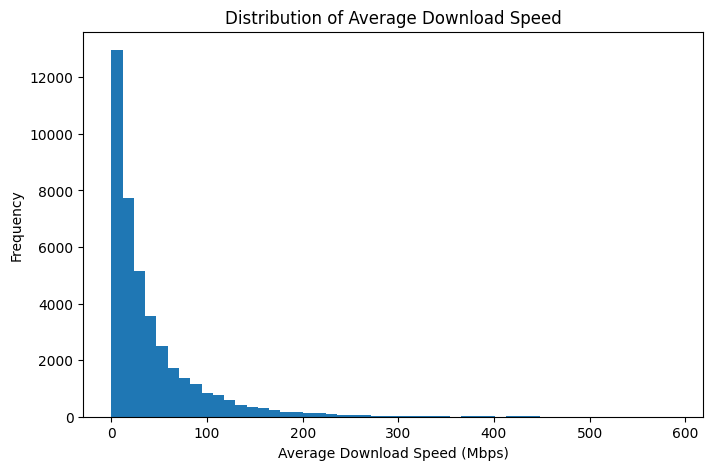

In [26]:
# Distribution of download speed

plt.figure(figsize=(8, 5))
plt.hist(plot_df["download_mbps"], bins=50)
plt.xlabel("Average Download Speed (Mbps)")
plt.ylabel("Frequency")
plt.title("Distribution of Average Download Speed")
plt.show()

#### interpretations:
The histogram shows that the distribution of average download speed is highly right-skewed. Most locations have relatively low download speeds, concentrated below 100 Mbps, while only a few areas have very high speeds reaching above 400 Mbps. This indicates unequal internet performance across locations, where high-speed connectivity is less common compared to moderate or slow download speeds.


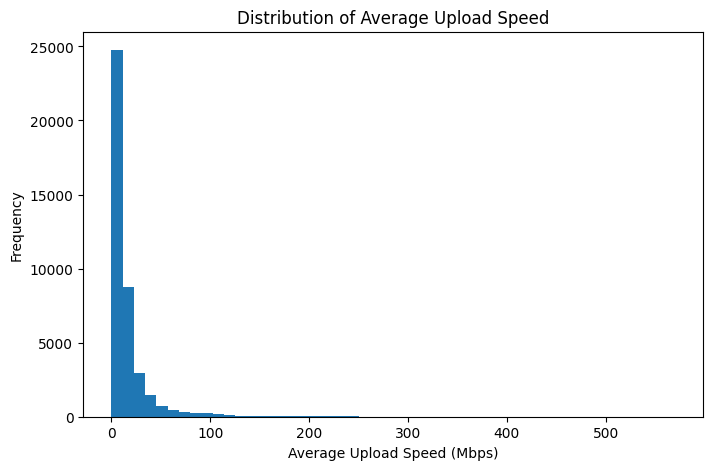

In [27]:
# Distribution of upload speed

plt.figure(figsize=(8, 5))
plt.hist(plot_df["upload_mbps"], bins=50)
plt.xlabel("Average Upload Speed (Mbps)")
plt.ylabel("Frequency")
plt.title("Distribution of Average Upload Speed")
plt.show()

#### interpretations:
The histogram shows that the distribution of average upload speed is also highly right-skewed. Most locations have low upload speeds, mainly concentrated below 50 Mbps, while only a small number of areas achieve very high upload speeds above 200 Mbps. This suggests that fast upload connectivity is less common and that upload performance varies significantly across different locations.

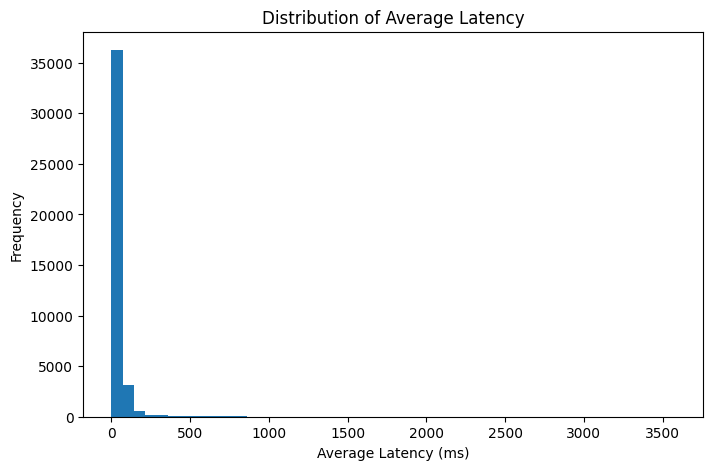

In [28]:
# Distribution of latency

plt.figure(figsize=(8, 5))
plt.hist(plot_df["latency_ms"], bins=50)
plt.xlabel("Average Latency (ms)")
plt.ylabel("Frequency")
plt.title("Distribution of Average Latency")
plt.show()

#### interpretations:
The histogram indicates that average latency is strongly right-skewed. Most locations experience relatively low latency values, concentrated below 100 ms, which suggests generally responsive network performance. However, there are a few extreme cases with very high latency reaching above 3000 ms, indicating occasional severe network delays or poor connectivity in some areas.

C:\Users\ACER\AppData\Local\Temp\ipykernel_14880\2418464023.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([fixed_download, mobile_download], labels=["Fixed", "Mobile"])


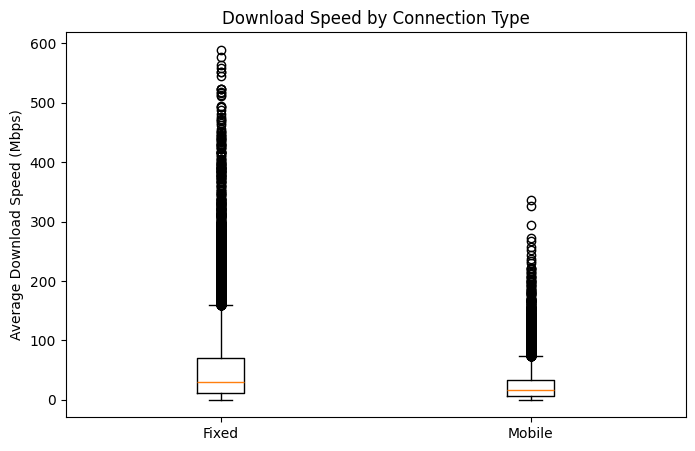

In [29]:
# Download speed comparison by connection type

fixed_download = plot_df.loc[plot_df["connection_type"] == "fixed", "download_mbps"]
mobile_download = plot_df.loc[plot_df["connection_type"] == "mobile", "download_mbps"]

plt.figure(figsize=(8, 5))
plt.boxplot([fixed_download, mobile_download], labels=["Fixed", "Mobile"])
plt.ylabel("Average Download Speed (Mbps)")
plt.title("Download Speed by Connection Type")
plt.show()

#### interpretations:
The boxplot shows that fixed connections generally provide higher download speeds than mobile connections. The median download speed for fixed networks is noticeably higher, and fixed connections also exhibit a wider spread of values, including extremely high-speed outliers above 500 Mbps. In contrast, mobile connections tend to have lower and more concentrated download speeds, although some high-speed outliers are still present. This suggests that fixed broadband offers more consistent and faster internet performance compared to mobile networks.


C:\Users\ACER\AppData\Local\Temp\ipykernel_14880\1685506056.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([fixed_latency, mobile_latency], labels=["Fixed", "Mobile"])


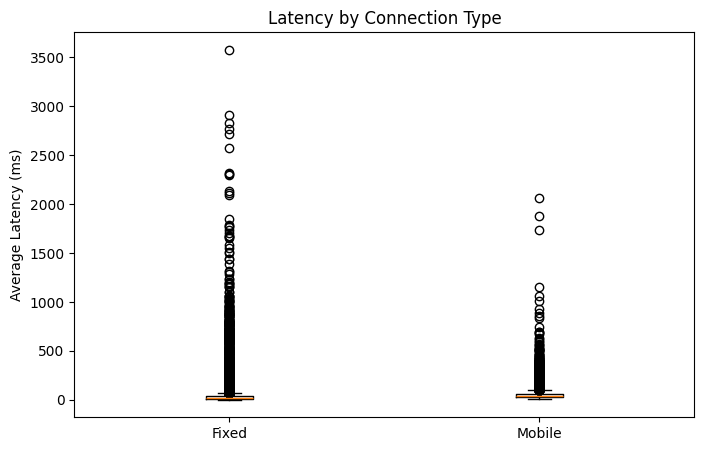

In [30]:
# Latency comparison by connection type

fixed_latency = plot_df.loc[plot_df["connection_type"] == "fixed", "latency_ms"]
mobile_latency = plot_df.loc[plot_df["connection_type"] == "mobile", "latency_ms"]

plt.figure(figsize=(8, 5))
plt.boxplot([fixed_latency, mobile_latency], labels=["Fixed", "Mobile"])
plt.ylabel("Average Latency (ms)")
plt.title("Latency by Connection Type")
plt.show()

#### interpretations:
The boxplot indicates that fixed connections generally have lower and more stable latency compared to mobile connections. Mobile networks show a slightly higher median latency and a wider spread of values, suggesting less consistent response times. Both connection types contain extreme latency outliers, but fixed connections exhibit more severe outliers reaching above 3500 ms. Overall, fixed broadband tends to provide more reliable low-latency performance, while mobile networks experience greater variability in network delay.


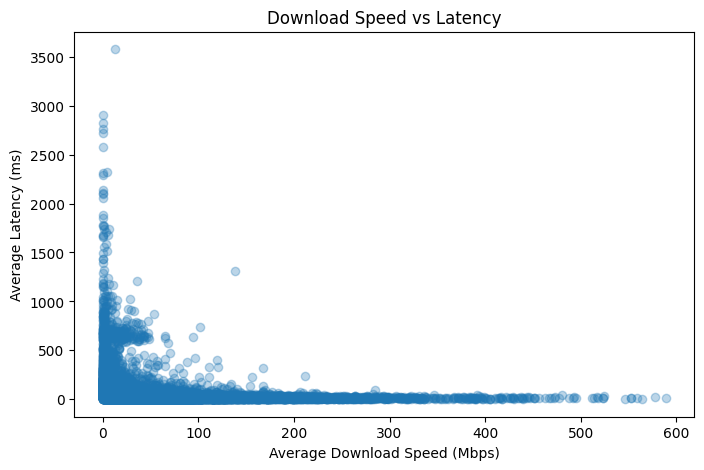

In [31]:
# Scatter plot of download speed and latency

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["download_mbps"], plot_df["latency_ms"], alpha=0.3)
plt.xlabel("Average Download Speed (Mbps)")
plt.ylabel("Average Latency (ms)")
plt.title("Download Speed vs Latency")
plt.show()

#### interpretations:
The scatter plot shows an inverse relationship between download speed and latency. As download speed increases, latency generally decreases and becomes more stable. Most high-speed connections are associated with low latency values, indicating better network performance and responsiveness. In contrast, lower download speeds exhibit a wide range of latency values, including several extreme delays, suggesting inconsistent and less reliable connectivity in slower networks.


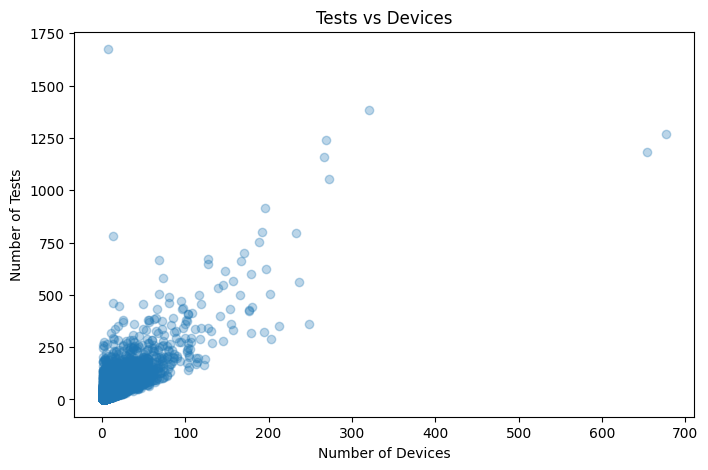

In [32]:
# Scatter plot of tests and devices

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["devices"], plot_df["tests"], alpha=0.3)
plt.xlabel("Number of Devices")
plt.ylabel("Number of Tests")
plt.title("Tests vs Devices")
plt.show()

#### interpretations:
The scatter plot shows a positive relationship between the number of devices and the number of tests conducted. Areas with more devices generally tend to have a higher number of tests, indicating increased user participation and network activity. Most data points are concentrated at lower values, while a few locations exhibit exceptionally large numbers of devices and tests, suggesting highly active or densely connected regions.


In [33]:
# Dataset storage audit

from pathlib import Path
import pandas as pd

def get_path_size_bytes(path):
    """
    Returns the size of a file or folder in bytes.
    """
    path = Path(path)

    if path.is_file():
        return path.stat().st_size

    if path.is_dir():
        return sum(
            file.stat().st_size
            for file in path.rglob("*")
            if file.is_file()
        )

    return 0


# Full dataset folder size including all file types
full_dataset_size_bytes = get_path_size_bytes(data_path)

# Parquet-only dataset size
parquet_size_bytes = sum(get_path_size_bytes(file) for file in parquet_files)

print("Full downloaded dataset folder size including all file types:")
print(f"{full_dataset_size_bytes / 1e9:.2f} GB")
print(f"{full_dataset_size_bytes / (1024 ** 3):.2f} GiB")

print("\nParquet-only dataset size:")
print(f"{parquet_size_bytes / 1e9:.2f} GB")
print(f"{parquet_size_bytes / (1024 ** 3):.2f} GiB")

print("\nNumber of Parquet files:", len(parquet_files))

Full downloaded dataset folder size including all file types:
37.80 GB
35.21 GiB

Parquet-only dataset size:
10.29 GB
9.58 GiB

Number of Parquet files: 24


# Setting the Final Project Dataframe (ookla_df)

In [34]:
# Set the final project dataframe
# This uses all available Parquet performance files.

project_df = ookla_df

print("Final project dataframe set.")
print("This dataframe uses all available Parquet files for feature engineering and scalable ML.")
print("Columns:", project_df.columns)

# Safe schema check only
project_df.printSchema()

Final project dataframe set.
This dataframe uses all available Parquet files for feature engineering and scalable ML.
Columns: ['quadkey', 'tile', 'avg_d_kbps', 'avg_u_kbps', 'avg_lat_ms', 'tests', 'devices', 'connection_type', 'year', 'quarter']
root
 |-- quadkey: string (nullable = true)
 |-- tile: string (nullable = true)
 |-- avg_d_kbps: long (nullable = true)
 |-- avg_u_kbps: long (nullable = true)
 |-- avg_lat_ms: long (nullable = true)
 |-- tests: long (nullable = true)
 |-- devices: long (nullable = true)
 |-- connection_type: string (nullable = false)
 |-- year: integer (nullable = false)
 |-- quarter: integer (nullable = false)



# 4. Data Cleaning and Feature Engineering

This section prepares the full Parquet-based project dataframe for scalable machine learning. Although the dataset is already structured and relatively clean, additional preprocessing is required to ensure that the variables are valid for clustering, dimensionality reduction, and regression modeling.

The feature engineering process includes:
1. Selecting relevant network-performance fields.
2. Casting numerical variables to double type.
3. Removing invalid records with null, zero, or negative values.
4. Converting speed measurements from kbps to Mbps.
5. Creating ratio-based features.
6. Applying log transformations to reduce skewness observed during EDA.

In [35]:
# Step 1: Define reusable cleaning and feature engineering function

from pyspark.sql import functions as F

def prepare_ookla_features(df):
    """
    Cleans and engineers features for the Ookla internet performance dataset.
    
    This function uses Spark transformations only. It is designed to work on both
    small debugging subsets and the full project dataframe.
    """
    
    featured = (
        df
        .select(
            "quadkey",
            "tile",
            "connection_type",
            "year",
            "quarter",
            F.col("avg_d_kbps").cast("double").alias("avg_d_kbps"),
            F.col("avg_u_kbps").cast("double").alias("avg_u_kbps"),
            F.col("avg_lat_ms").cast("double").alias("avg_lat_ms"),
            F.col("tests").cast("double").alias("tests"),
            F.col("devices").cast("double").alias("devices")
        )
        .dropna(subset=[
            "quadkey",
            "connection_type",
            "year",
            "quarter",
            "avg_d_kbps",
            "avg_u_kbps",
            "avg_lat_ms",
            "tests",
            "devices"
        ])
        .filter(F.col("avg_d_kbps") > 0)
        .filter(F.col("avg_u_kbps") > 0)
        .filter(F.col("avg_lat_ms") > 0)
        .filter(F.col("tests") > 0)
        .filter(F.col("devices") > 0)
        .withColumn("download_mbps", F.col("avg_d_kbps") / 1000.0)
        .withColumn("upload_mbps", F.col("avg_u_kbps") / 1000.0)
        .withColumn("latency_ms", F.col("avg_lat_ms"))
        .withColumn("download_upload_ratio", F.col("download_mbps") / F.col("upload_mbps"))
        .withColumn("tests_per_device", F.col("tests") / F.col("devices"))
        .withColumn("log_download_mbps", F.log1p(F.col("download_mbps")))
        .withColumn("log_upload_mbps", F.log1p(F.col("upload_mbps")))
        .withColumn("log_latency_ms", F.log1p(F.col("latency_ms")))
        .withColumn("log_tests", F.log1p(F.col("tests")))
        .withColumn("log_devices", F.log1p(F.col("devices")))
    )
    
    return featured

print("Feature engineering function defined successfully.")

Feature engineering function defined successfully.


The preprocessing logic is written as a reusable function instead of a one-time transformation. This supports reproducibility because the same function can be applied to a pilot subset, a single Parquet file for debugging, or the full project dataframe. This also makes the implementation scalable because the transformations are expressed using PySpark operations rather than local pandas processing.

#### applying the function to the full project dataframe

In [36]:
# Step 2: Apply feature engineering to the full project dataframe

featured_df = prepare_ookla_features(project_df)

print("Feature engineering transformations applied to project_df.")
print("No full-data action has been triggered yet.")
print("Number of columns:", len(featured_df.columns))
print("Columns:")
print(featured_df.columns)

Feature engineering transformations applied to project_df.
No full-data action has been triggered yet.
Number of columns: 20
Columns:
['quadkey', 'tile', 'connection_type', 'year', 'quarter', 'avg_d_kbps', 'avg_u_kbps', 'avg_lat_ms', 'tests', 'devices', 'download_mbps', 'upload_mbps', 'latency_ms', 'download_upload_ratio', 'tests_per_device', 'log_download_mbps', 'log_upload_mbps', 'log_latency_ms', 'log_tests', 'log_devices']


In [37]:
featured_df.printSchema()

root
 |-- quadkey: string (nullable = true)
 |-- tile: string (nullable = true)
 |-- connection_type: string (nullable = false)
 |-- year: integer (nullable = false)
 |-- quarter: integer (nullable = false)
 |-- avg_d_kbps: double (nullable = true)
 |-- avg_u_kbps: double (nullable = true)
 |-- avg_lat_ms: double (nullable = true)
 |-- tests: double (nullable = true)
 |-- devices: double (nullable = true)
 |-- download_mbps: double (nullable = true)
 |-- upload_mbps: double (nullable = true)
 |-- latency_ms: double (nullable = true)
 |-- download_upload_ratio: double (nullable = true)
 |-- tests_per_device: double (nullable = true)
 |-- log_download_mbps: double (nullable = true)
 |-- log_upload_mbps: double (nullable = true)
 |-- log_latency_ms: double (nullable = true)
 |-- log_tests: double (nullable = true)
 |-- log_devices: double (nullable = true)



The engineered dataframe now contains both the original network-performance variables and additional machine-learning features. Speed variables were converted from kbps to Mbps for interpretability. Ratio features were added to capture relationships between download and upload performance, as well as testing intensity per device.

Log-transformed variables were created because the EDA visualizations showed that speed, latency, tests, and devices are likely skewed. These log features are useful for models that are sensitive to scale and extreme values, especially K-Means, PCA, and Linear Regression.

In [38]:
# Step 3: Define candidate ML feature columns

numeric_feature_cols = [
    "log_download_mbps",
    "log_upload_mbps",
    "log_tests",
    "log_devices",
    "download_upload_ratio",
    "tests_per_device",
    "year",
    "quarter"
]

target_col = "log_latency_ms"

print("Candidate numerical feature columns:")
for col in numeric_feature_cols:
    print("-", col)

print("\nRegression target column:")
print("-", target_col)

Candidate numerical feature columns:
- log_download_mbps
- log_upload_mbps
- log_tests
- log_devices
- download_upload_ratio
- tests_per_device
- year
- quarter

Regression target column:
- log_latency_ms


In [39]:
# Step 4: Safe feature PREVIEW using one Parquet file only

from pathlib import Path

preview_file = parquet_files[0]
preview_path = Path(preview_file)
preview_folder = preview_path.parent.name

preview_year = int(preview_folder.split("-q")[0])
preview_quarter = int(preview_folder.split("-q")[1])

if "fixed" in preview_path.name.lower():
    preview_connection_type = "fixed"
elif "mobile" in preview_path.name.lower():
    preview_connection_type = "mobile"
else:
    preview_connection_type = "unknown"

preview_df = (
    spark.read.parquet(str(preview_path))
    .withColumn("connection_type", F.lit(preview_connection_type))
    .withColumn("year", F.lit(preview_year))
    .withColumn("quarter", F.lit(preview_quarter))
)

preview_featured_df = prepare_ookla_features(preview_df)

preview_featured_df.select(
    "connection_type",
    "year",
    "quarter",
    "download_mbps",
    "upload_mbps",
    "latency_ms",
    "download_upload_ratio",
    "tests_per_device",
    "log_download_mbps",
    "log_upload_mbps",
    "log_latency_ms",
    "log_tests",
    "log_devices"
).limit(10).show(truncate=False)

+---------------+----+-------+-------------+-----------+----------+---------------------+------------------+-------------------+-------------------+------------------+------------------+------------------+
|connection_type|year|quarter|download_mbps|upload_mbps|latency_ms|download_upload_ratio|tests_per_device  |log_download_mbps  |log_upload_mbps    |log_latency_ms    |log_tests         |log_devices       |
+---------------+----+-------+-------------+-----------+----------+---------------------+------------------+-------------------+-------------------+------------------+------------------+------------------+
|fixed          |2019|1      |66.216       |12.49      |13.0      |5.301521216973578    |7.0               |4.207911314427026  |2.6019486702196644 |2.639057329615259 |3.367295829986474 |1.6094379124341003|
|fixed          |2019|1      |102.598      |37.356     |13.0      |2.7464932005568046   |3.75              |4.640518024619733  |3.6469109692914348 |2.639057329615259 |2.7725887

# 5. Scalable ML Preprocessing

This section prepares the engineered `featured_df` for scalable machine learning using PySpark ML. Since PySpark ML algorithms require numerical feature vectors, the categorical `connection_type` column is encoded, selected numerical predictors are assembled into a single feature vector, and the resulting feature vector is standardized.

The output of this section is `ml_df`, which will be used for K-Means clustering, PCA, and regression modeling.

In [40]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler

In [41]:
# Step 2: Define features and target

numeric_feature_cols = [
    "log_download_mbps",
    "log_upload_mbps",
    "log_tests",
    "log_devices",
    "download_upload_ratio",
    "tests_per_device",
    "year",
    "quarter"
]

categorical_col = "connection_type"
indexed_categorical_col = "connection_type_index"

target_col = "log_latency_ms"

print("Numerical feature columns:")
for col in numeric_feature_cols:
    print("-", col)

print("\nCategorical feature:")
print("-", categorical_col)

print("\nRegression target column:")
print("-", target_col)

Numerical feature columns:
- log_download_mbps
- log_upload_mbps
- log_tests
- log_devices
- download_upload_ratio
- tests_per_device
- year
- quarter

Categorical feature:
- connection_type

Regression target column:
- log_latency_ms


In [42]:
# Step 3: Define preprocessing stages

connection_indexer = StringIndexer(
    inputCol=categorical_col,
    outputCol=indexed_categorical_col,
    handleInvalid="keep"
)

assembler = VectorAssembler(
    inputCols=numeric_feature_cols + [indexed_categorical_col],
    outputCol="raw_features",
    handleInvalid="skip"
)

scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="scaled_features",
    withStd=True,
    withMean=True
)

ml_preprocessing_pipeline = Pipeline(
    stages=[
        connection_indexer,
        assembler,
        scaler
    ]
)

print("ML preprocessing pipeline defined.")

ML preprocessing pipeline defined.


In [43]:
# Step 4: Fit and transform preprocessing pipeline on featured_df

ml_preprocessing_model = ml_preprocessing_pipeline.fit(featured_df)

ml_df = ml_preprocessing_model.transform(featured_df)

print("ML preprocessing pipeline fitted and transformed.")
print("ML-ready dataframe created as ml_df.")
print("Columns:")
print(ml_df.columns)

ML preprocessing pipeline fitted and transformed.
ML-ready dataframe created as ml_df.
Columns:
['quadkey', 'tile', 'connection_type', 'year', 'quarter', 'avg_d_kbps', 'avg_u_kbps', 'avg_lat_ms', 'tests', 'devices', 'download_mbps', 'upload_mbps', 'latency_ms', 'download_upload_ratio', 'tests_per_device', 'log_download_mbps', 'log_upload_mbps', 'log_latency_ms', 'log_tests', 'log_devices', 'connection_type_index', 'raw_features', 'scaled_features']


In [45]:
# Step 5: Inspect ML-ready dataframe schema

ml_df.select(
    "connection_type",
    "connection_type_index",
    "raw_features",
    "scaled_features",
    target_col
).printSchema()

root
 |-- connection_type: string (nullable = false)
 |-- connection_type_index: double (nullable = false)
 |-- raw_features: vector (nullable = true)
 |-- scaled_features: vector (nullable = true)
 |-- log_latency_ms: double (nullable = true)



In [46]:
# Step 6: Preview ML-ready rows

ml_df.select(
    "connection_type",
    "connection_type_index",
    "raw_features",
    "scaled_features",
    target_col
).limit(5).show(truncate=False)

+---------------+---------------------+------------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|connection_type|connection_type_index|raw_features                                                                                                                  |scaled_features                                                                                                                                                                     |log_latency_ms    |
+---------------+---------------------+------------------------------------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------

The ML preprocessing pipeline successfully produced an ML-ready dataframe. The categorical `connection_type` column was encoded into `connection_type_index`, while the selected numerical and encoded categorical variables were assembled into `raw_features`. These raw feature vectors were then standardized into `scaled_features`.

The preview shows that each row now contains both the original engineered variables and the vectorized features required by PySpark ML algorithms. The standardized features may contain negative values because standardization centers variables around their mean. This is expected and is especially important for distance-based and variance-based methods such as K-Means clustering and PCA.

# 6. Scalable ML Model 1: K-Means Clustering

This section applies K-Means clustering to the ML-ready dataframe. The goal is to group internet-performance tiles into distinct performance tiers based on the engineered and scaled features.

K-Means is appropriate for this task because it can identify groups of observations with similar network-performance characteristics. In this project, the resulting clusters are interpreted as data-driven internet performance tiers rather than manually assigned labels.

In [47]:
# Step 1: Create clustering dataframe

cluster_df = ml_df.select(
    "quadkey",
    "tile",
    "connection_type",
    "year",
    "quarter",
    "download_mbps",
    "upload_mbps",
    "latency_ms",
    "tests",
    "devices",
    "download_upload_ratio",
    "tests_per_device",
    "scaled_features"
).dropna(subset=["scaled_features"])

print("Clustering dataframe defined.")
print("Columns:")
print(cluster_df.columns)

cluster_df.select(
    "connection_type",
    "year",
    "quarter",
    "scaled_features"
).printSchema()

Clustering dataframe defined.
Columns:
['quadkey', 'tile', 'connection_type', 'year', 'quarter', 'download_mbps', 'upload_mbps', 'latency_ms', 'tests', 'devices', 'download_upload_ratio', 'tests_per_device', 'scaled_features']
root
 |-- connection_type: string (nullable = false)
 |-- year: integer (nullable = false)
 |-- quarter: integer (nullable = false)
 |-- scaled_features: vector (nullable = true)



In [48]:
# Train K-Means model

from pyspark.ml.clustering import KMeans

kmeans = KMeans(
    featuresCol="scaled_features",
    predictionCol="cluster",
    k=3,
    seed=42,
    maxIter=20,
    initMode="k-means||"
)

kmeans_model = kmeans.fit(cluster_df)

clustered_df = kmeans_model.transform(cluster_df)

print("K-Means model trained successfully.")
print("Clustered dataframe created.")

K-Means model trained successfully.
Clustered dataframe created.


In [49]:
# Step 6.3: Evaluate K-Means clustering using silhouette score

from pyspark.ml.evaluation import ClusteringEvaluator

clustering_evaluator = ClusteringEvaluator(
    featuresCol="scaled_features",
    predictionCol="cluster",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

silhouette_score = clustering_evaluator.evaluate(clustered_df)

print(f"Silhouette score for K-Means with k=3: {silhouette_score:.4f}")

Silhouette score for K-Means with k=3: 0.2394


The silhouette score evaluates how well-separated the clusters are. Values closer to 1 indicate more distinct clusters, while values near 0 suggest overlapping clusters. Since the dataset represents real-world network performance rather than clearly separated artificial groups, moderate or low silhouette values may still be expected.

The K-Means model produced a silhouette score of 0.2394 for k=3. This indicates that the clusters have some separation, although the boundaries are not highly distinct. This result is reasonable for real-world internet performance data because network quality exists along a continuous spectrum rather than in perfectly separated categories. Therefore, the clusters are interpreted as approximate performance tiers rather than absolute classes.

In [50]:
# Step 6.4: Preview K-Means cluster assignments

clustered_df.select(
    "connection_type",
    "year",
    "quarter",
    "download_mbps",
    "upload_mbps",
    "latency_ms",
    "tests",
    "devices",
    "download_upload_ratio",
    "tests_per_device",
    "cluster"
).limit(10).show(truncate=False)

+---------------+----+-------+-------------+-----------+----------+-----+-------+---------------------+------------------+-------+
|connection_type|year|quarter|download_mbps|upload_mbps|latency_ms|tests|devices|download_upload_ratio|tests_per_device  |cluster|
+---------------+----+-------+-------------+-----------+----------+-----+-------+---------------------+------------------+-------+
|fixed          |2019|1      |66.216       |12.49      |13.0      |28.0 |4.0    |5.301521216973578    |7.0               |0      |
|fixed          |2019|1      |102.598      |37.356     |13.0      |15.0 |4.0    |2.7464932005568046   |3.75              |0      |
|fixed          |2019|1      |24.686       |18.736     |18.0      |162.0|106.0  |1.3175704526046115   |1.528301886792453 |0      |
|fixed          |2019|1      |17.674       |13.989     |78.0      |364.0|4.0    |1.2634212595610836   |91.0              |0      |
|fixed          |2019|1      |441.192      |218.955    |22.0      |14.0 |1.0    |2.

In [51]:
# Step 6.5: Count number of records per cluster

cluster_counts = (
    clustered_df
    .groupBy("cluster")
    .count()
    .orderBy("cluster")
)

cluster_counts.show(truncate=False)

+-------+--------+
|cluster|count   |
+-------+--------+
|0      |24345817|
|1      |44716375|
|2      |54295519|
+-------+--------+



In [52]:
# Step 6.6: Summarize cluster characteristics

from pyspark.sql import functions as F

cluster_summary = (
    clustered_df
    .groupBy("cluster")
    .agg(
        F.count("*").alias("records"),
        F.round(F.avg("download_mbps"), 2).alias("avg_download_mbps"),
        F.round(F.avg("upload_mbps"), 2).alias("avg_upload_mbps"),
        F.round(F.avg("latency_ms"), 2).alias("avg_latency_ms"),
        F.round(F.avg("tests"), 2).alias("avg_tests"),
        F.round(F.avg("devices"), 2).alias("avg_devices"),
        F.round(F.avg("download_upload_ratio"), 2).alias("avg_download_upload_ratio"),
        F.round(F.avg("tests_per_device"), 2).alias("avg_tests_per_device")
    )
    .orderBy("cluster")
)

cluster_summary.show(truncate=False)

+-------+--------+-----------------+---------------+--------------+---------+-----------+-------------------------+--------------------+
|cluster|records |avg_download_mbps|avg_upload_mbps|avg_latency_ms|avg_tests|avg_devices|avg_download_upload_ratio|avg_tests_per_device|
+-------+--------+-----------------+---------------+--------------+---------+-----------+-------------------------+--------------------+
|0      |24345817|78.86            |33.11          |22.75         |67.14    |17.29      |3.71                     |5.4                 |
|1      |44716375|101.74           |42.1           |21.26         |4.04     |1.92       |4.62                     |2.2                 |
|2      |54295519|14.86            |5.02           |55.69         |3.36     |1.63       |14.11                    |2.07                |
+-------+--------+-----------------+---------------+--------------+---------+-----------+-------------------------+--------------------+



The cluster summary shows three distinct internet performance patterns. Cluster 1 represents the strongest-performing tier, with the highest average download and upload speeds and the lowest average latency. Cluster 0 also shows relatively strong performance, but it has much higher average tests and devices, suggesting that it may represent more actively measured or denser network areas. Cluster 2 represents the weakest-performing tier, with substantially lower download and upload speeds and much higher latency.

Based on these results, the clusters can be interpreted as: Cluster 1 = high-performance tier, Cluster 0 = stable/high-activity performance tier, and Cluster 2 = low-performance tier.

In [53]:
# Step 6.7: Cluster distribution by connection type

cluster_connection_summary = (
    clustered_df
    .groupBy("cluster", "connection_type")
    .agg(F.count("*").alias("records"))
    .orderBy("cluster", "connection_type")
)

cluster_connection_summary.show(truncate=False)

+-------+---------------+--------+
|cluster|connection_type|records |
+-------+---------------+--------+
|0      |fixed          |19836970|
|0      |mobile         |4508847 |
|1      |fixed          |34293545|
|1      |mobile         |10422830|
|2      |fixed          |21413965|
|2      |mobile         |32881554|
+-------+---------------+--------+



The connection-type distribution shows that Cluster 0 and Cluster 1 are mostly composed of fixed network records, while Cluster 2 contains more mobile records than fixed records. This suggests that lower-performing network conditions in the dataset are more strongly associated with mobile connections, while higher-performing clusters are more strongly associated with fixed broadband records.

In [54]:
# Pivot table of clusters by connection type

cluster_connection_pivot = (
    clustered_df
    .groupBy("cluster")
    .pivot("connection_type")
    .count()
    .orderBy("cluster")
)

cluster_connection_pivot.show(truncate=False)

+-------+--------+--------+
|cluster|fixed   |mobile  |
+-------+--------+--------+
|0      |19836970|4508847 |
|1      |34293545|10422830|
|2      |21413965|32881554|
+-------+--------+--------+



In [55]:
# Step 6.8: Cluster distribution by year and quarter

cluster_time_summary = (
    clustered_df
    .groupBy("year", "quarter", "cluster")
    .agg(F.count("*").alias("records"))
    .orderBy("year", "quarter", "cluster")
)

cluster_time_summary.show(100, truncate=False)

+----+-------+-------+-------+
|year|quarter|cluster|records|
+----+-------+-------+-------+
|2019|1      |0      |1396255|
|2019|1      |1      |2092302|
|2019|1      |2      |4619638|
|2019|2      |0      |1370351|
|2019|2      |1      |2221941|
|2019|2      |2      |4605355|
|2019|3      |0      |1795514|
|2019|3      |1      |2677048|
|2019|3      |2      |5084791|
|2019|4      |0      |2248282|
|2019|4      |1      |3150378|
|2019|4      |2      |4897925|
|2020|1      |0      |2294235|
|2020|1      |1      |3402594|
|2020|1      |2      |4894846|
|2020|2      |0      |2389266|
|2020|2      |1      |3638016|
|2020|2      |2      |4987162|
|2020|3      |0      |2292059|
|2020|3      |1      |3928062|
|2020|3      |2      |4990763|
|2020|4      |0      |2117138|
|2020|4      |1      |4003666|
|2020|4      |2      |4381752|
|2021|1      |0      |2201623|
|2021|1      |1      |4398739|
|2021|1      |2      |4213056|
|2021|2      |0      |2080391|
|2021|2      |1      |4790061|
|2021|2 

The year-quarter distribution shows that all clusters appear across all time periods, meaning the K-Means model did not create clusters that are limited to only one year or quarter. However, the number of records in Cluster 1 generally increases over time, while Cluster 2 decreases in later quarters. This may suggest a shift toward stronger measured network performance over time, although this should be interpreted carefully because record counts may also be affected by changes in measurement coverage.

# 7. K-means visualizations

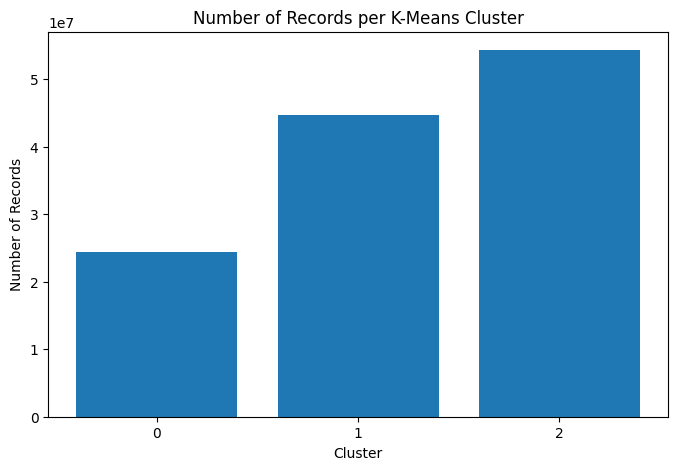

In [ ]:
# records per cluster

cluster_counts_pd = cluster_counts.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts_pd["cluster"], cluster_counts_pd["count"])
plt.xlabel("Cluster")
plt.ylabel("Number of Records")
plt.title("Number of Records per K-Means Cluster")
plt.xticks(cluster_counts_pd["cluster"])
plt.show()

The bar chart shows that the K-Means model did not divide the dataset into equally sized clusters. Cluster 2 contains the largest number of records, followed by Cluster 1, while Cluster 0 contains the fewest records. Based on the cluster counts, Cluster 2 has around 54.3 million records, Cluster 1 has around 44.7 million records, and Cluster 0 has around 24.3 million records.

This uneven distribution is expected in real-world internet performance data because network conditions are not evenly distributed across geographic tiles and connection types. A larger cluster may represent the most common type of network-performance pattern in the dataset, while smaller clusters may represent more specific or less frequent patterns.

Since Cluster 2 was later shown to have the lowest average download and upload speeds and the highest latency, its large size suggests that lower-performance network conditions make up a substantial portion of the dataset. This supports the usefulness of clustering because it reveals that internet performance records are not only different in quality, but also unevenly distributed across performance tiers.

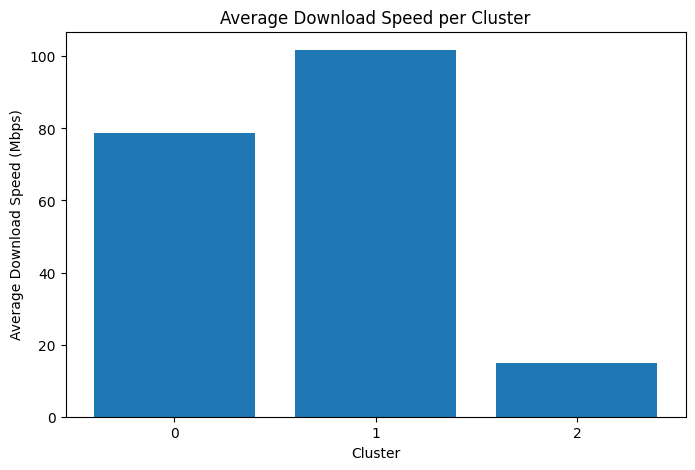

In [57]:
# average download speed per cluster

cluster_summary_pd = cluster_summary.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(cluster_summary_pd["cluster"], cluster_summary_pd["avg_download_mbps"])
plt.xlabel("Cluster")
plt.ylabel("Average Download Speed (Mbps)")
plt.title("Average Download Speed per Cluster")
plt.xticks(cluster_summary_pd["cluster"])
plt.show()

The chart shows clear differences in average download speed across the three K-Means clusters. Cluster 1 has the highest average download speed at around 101.74 Mbps, followed by Cluster 0 at around 78.86 Mbps. Cluster 2 has a much lower average download speed at around 14.86 Mbps.

This suggests that Cluster 1 represents the strongest download-performance tier, while Cluster 0 represents a moderately strong or stable-performance tier. Cluster 2 represents the lowest download-performance tier. The large gap between Cluster 2 and the other two clusters shows that K-Means was able to separate records with substantially weaker download performance from records with stronger network performance.

This result supports the goal of the project because the clustering model produces interpretable internet performance tiers based on observed network behavior.

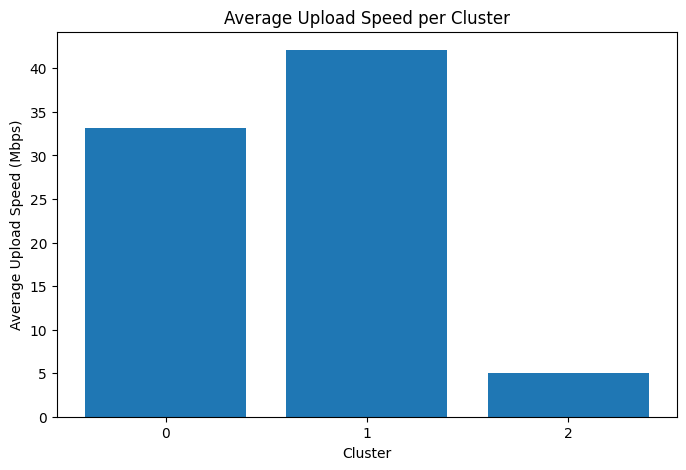

In [58]:
# Average upload speed per cluster

plt.figure(figsize=(8, 5))
plt.bar(cluster_summary_pd["cluster"], cluster_summary_pd["avg_upload_mbps"])
plt.xlabel("Cluster")
plt.ylabel("Average Upload Speed (Mbps)")
plt.title("Average Upload Speed per Cluster")
plt.xticks(cluster_summary_pd["cluster"])
plt.show()

The upload speed pattern is similar to the download speed pattern. Cluster 1 has the highest average upload speed at around 42.10 Mbps, followed by Cluster 0 at around 33.11 Mbps. Cluster 2 has the lowest average upload speed at around 5.02 Mbps.

This strengthens the interpretation of Cluster 1 as the high-performance internet tier and Cluster 2 as the low-performance tier. The large difference between Cluster 2 and the other clusters suggests that lower-performing records are not only slower in download speed, but also significantly weaker in upload performance.

Upload speed is important because it affects tasks such as video calls, file sharing, online classes, remote work, and cloud-based activities. Therefore, the low upload speed of Cluster 2 indicates a broader limitation in network quality, not just weaker download throughput.

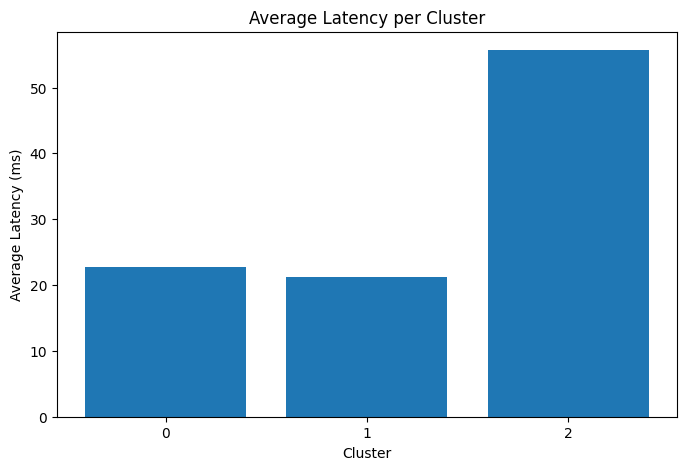

In [59]:
# Average latency per cluster

plt.figure(figsize=(8, 5))
plt.bar(cluster_summary_pd["cluster"], cluster_summary_pd["avg_latency_ms"])
plt.xlabel("Cluster")
plt.ylabel("Average Latency (ms)")
plt.title("Average Latency per Cluster")
plt.xticks(cluster_summary_pd["cluster"])
plt.show()

Since latency was not included in our K-means scaled_features, we're simply using it a post-clustering validation to confirm and help with interpreations

The latency chart shows that Cluster 2 has the highest average latency at around 55.69 ms, while Cluster 0 and Cluster 1 have much lower average latency values at around 22.75 ms and 21.26 ms, respectively. Since lower latency indicates better network responsiveness, this confirms that Cluster 2 represents the weakest performance tier.

This result strengthens the earlier speed-based interpretation. Cluster 2 is not only slower in download and upload speed, but also less responsive. In contrast, Cluster 1 has the best overall performance because it combines the highest average download and upload speeds with the lowest average latency. Cluster 0 also performs relatively well, although it is slightly slower than Cluster 1.

Overall, the latency pattern supports the interpretation of the clusters as internet performance tiers: Cluster 1 as the high-performance tier, Cluster 0 as the stable/moderate-to-strong tier, and Cluster 2 as the low-performance tier.

<Figure size 800x500 with 0 Axes>

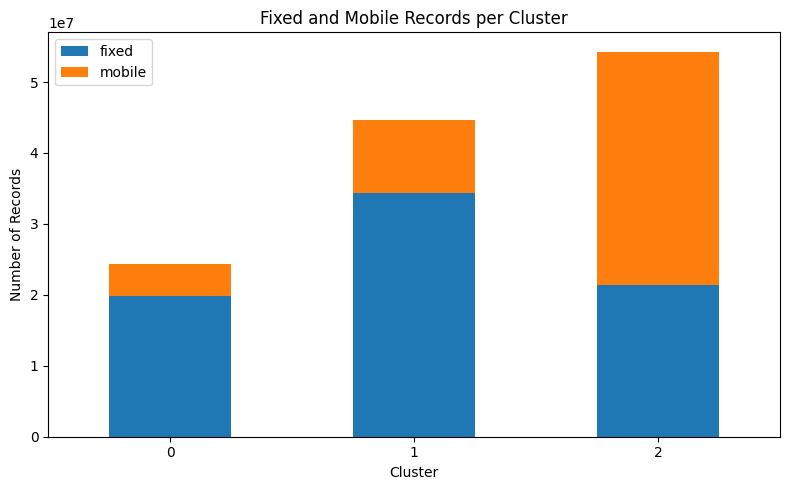

In [63]:
# Visualization 5: Fixed vs Mobile Records per Cluster

import matplotlib.pyplot as plt

cluster_connection_pivot_pd = cluster_connection_pivot.toPandas().fillna(0)

plt.figure(figsize=(8, 5))

cluster_connection_pivot_pd.plot(
    x="cluster",
    y=["fixed", "mobile"],
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.xlabel("Cluster")
plt.ylabel("Number of Records")
plt.title("Fixed and Mobile Records per Cluster")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The stacked bar chart shows the distribution of fixed and mobile records within each K-Means cluster. Cluster 0 and Cluster 1 are mostly composed of fixed connection records, while Cluster 2 contains more mobile records than fixed records.

This pattern supports the earlier performance-tier interpretation. Cluster 1, which had the highest average download and upload speeds and the lowest latency, is strongly dominated by fixed broadband records. Cluster 0 is also mostly fixed and represents a stable or moderate-to-strong performance tier. In contrast, Cluster 2, which had the lowest speeds and highest latency, contains a larger share of mobile records.

This suggests that connection type is an important factor in the clustering structure. Fixed broadband records are more associated with stronger-performing tiers, while mobile records are more concentrated in the lower-performing tier. This may reflect the greater variability of mobile networks compared with fixed broadband infrastructure.

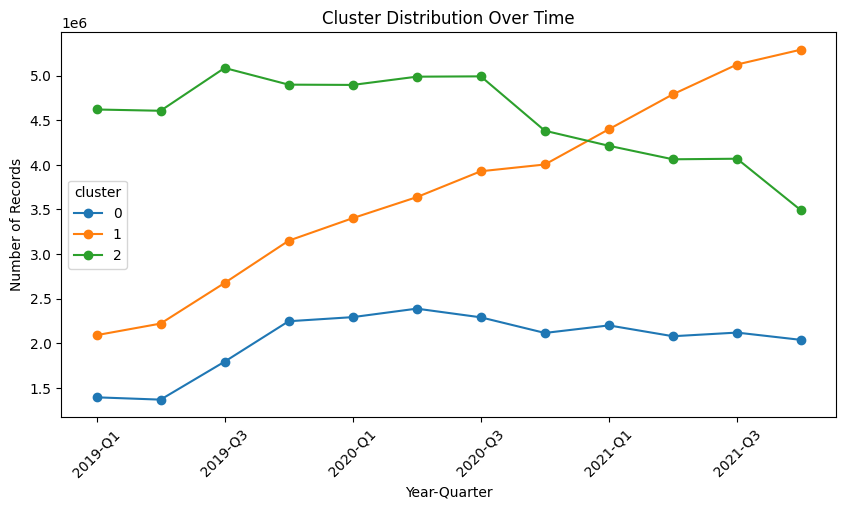

In [61]:
# CLuster disribution over time

cluster_time_pd = cluster_time_summary.toPandas()

cluster_time_pd["period"] = (
    cluster_time_pd["year"].astype(str) + "-Q" + cluster_time_pd["quarter"].astype(str)
)

cluster_time_pivot = cluster_time_pd.pivot(
    index="period",
    columns="cluster",
    values="records"
).fillna(0)

cluster_time_pivot.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.xlabel("Year-Quarter")
plt.ylabel("Number of Records")
plt.title("Cluster Distribution Over Time")
plt.xticks(rotation=45)
plt.show()

The cluster distribution over time shows a noticeable shift in the composition of internet performance records from 2019 to 2021. Cluster 1 steadily increases across the quarters, starting at around 2.1 million records in 2019-Q1 and reaching around 5.3 million records by 2021-Q4. Since Cluster 1 represents the high-performance tier, this suggests that a growing portion of the dataset is being classified into stronger-performing network conditions over time.

Cluster 2 shows the opposite pattern. It starts as the largest cluster in 2019, with more than 4.6 million records, remains high through much of 2020, and then declines sharply in 2021. Since Cluster 2 represents the low-performance tier, this may suggest a reduction in weaker-performing records over time.

Cluster 0 stays relatively stable compared with the other two clusters. It increases from 2019 to early 2020, then remains around 2.0 to 2.4 million records in later quarters. This supports its interpretation as a stable or moderate-to-strong performance tier.

Overall, the time-based distribution suggests a possible shift from lower-performance records toward higher-performance records across the observed period. However, this should be interpreted carefully because changes in record counts may also reflect changes in Speedtest usage, device coverage, data availability, or measurement density rather than infrastructure improvement alone.

## Spatial Visualization of K-Means Clusters

To visually inspect the geographic distribution of the K-Means clusters, a sampled set of clustered records was plotted using the approximate centroid of each Ookla tile. Since the `tile` column contains polygon geometry, the longitude and latitude of each tile were estimated from its polygon bounds. The full dataset was not converted to pandas; only a small sample was collected for visualization.

In [93]:
# Safer spatial plotting sample from clustered_df

spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "false")

spatial_plot_df = (
    clustered_df
    .select("tile", "cluster")
    .dropna(subset=["tile", "cluster"])
    .sample(withReplacement=False, fraction=0.0001, seed=42)
    .limit(10000)
    .toPandas()
)

print("Spatial plotting sample shape:", spatial_plot_df.shape)
spatial_plot_df.head()

Spatial plotting sample shape: (10000, 2)


,tile,cluster
0,"POLYGON((-86.9842529296875 35.6885332073887, -...",0
1,"POLYGON((11.832275390625 44.6959929817207, 11....",0
2,"POLYGON((-73.7457275390625 43.1049935816055, -...",1
3,"POLYGON((-64.6710205078125 10.2068130724846, -...",0
4,"POLYGON((-0.0714111328125 51.6589266488005, -0...",0


In [94]:
import re
import numpy as np

def extract_tile_centroid(wkt):
    try:
        numbers = [float(x) for x in re.findall(r"-?\d+\.\d+|-?\d+", wkt)]
        coords = list(zip(numbers[0::2], numbers[1::2]))

        if len(coords) == 0:
            return np.nan, np.nan

        lons = [coord[0] for coord in coords]
        lats = [coord[1] for coord in coords]

        centroid_lon = (min(lons) + max(lons)) / 2
        centroid_lat = (min(lats) + max(lats)) / 2

        return centroid_lon, centroid_lat

    except Exception:
        return np.nan, np.nan


spatial_plot_df[["longitude", "latitude"]] = spatial_plot_df["tile"].apply(
    lambda x: pd.Series(extract_tile_centroid(x))
)

spatial_plot_df = spatial_plot_df.dropna(subset=["longitude", "latitude"])

spatial_plot_df.head()

,tile,cluster,longitude,latitude
0,"POLYGON((-86.9842529296875 35.6885332073887, -...",0,-86.981506,35.686302
1,"POLYGON((11.832275390625 44.6959929817207, 11....",0,11.835022,44.694041
2,"POLYGON((-73.7457275390625 43.1049935816055, -...",1,-73.742981,43.102988
3,"POLYGON((-64.6710205078125 10.2068130724846, -...",0,-64.668274,10.204110
4,"POLYGON((-0.0714111328125 51.6589266488005, -0...",0,-0.068665,51.657223


#### Spatial Distribution of K-Means Internet Performance Tiers

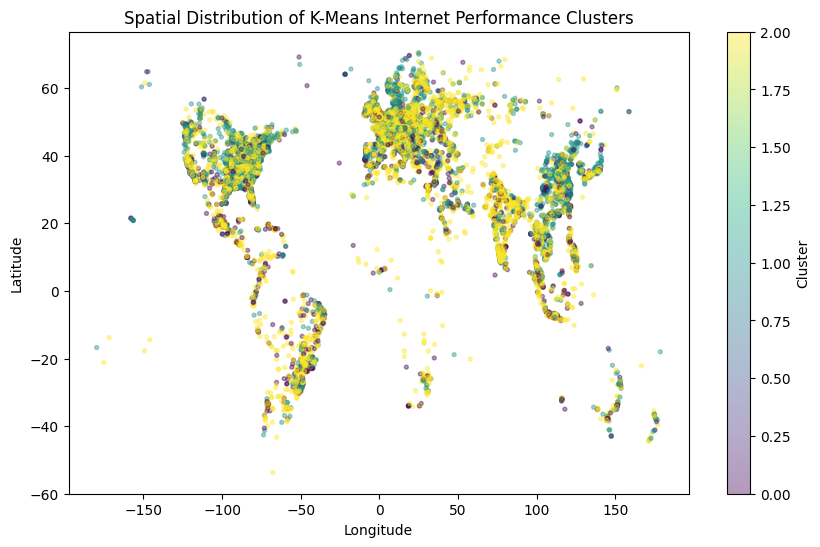

In [95]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    spatial_plot_df["longitude"],
    spatial_plot_df["latitude"],
    c=spatial_plot_df["cluster"],
    alpha=0.4,
    s=8
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of K-Means Internet Performance Clusters")
plt.colorbar(scatter, label="Cluster")
plt.show()

#### Interpretation:
The spatial scatter plot shows the approximate geographic distribution of the K-Means internet performance clusters using sampled tile centroids. The points form a recognizable global pattern, confirming that the tile geometries were successfully converted into approximate longitude and latitude coordinates.

The plot shows that all three clusters appear across multiple regions rather than being limited to a single continent or area. This suggests that the K-Means clusters represent network-performance patterns that occur globally, not purely geographic regions. In other words, the model grouped records based on performance characteristics, while this visualization shows where those performance tiers appear in space.

Cluster 2, previously interpreted as the low-performance tier, appears widely distributed across many regions. This supports the earlier finding that lower-performance records make up a large portion of the dataset. Clusters 0 and 1 also appear across different regions, showing that stronger and moderate-performing network conditions are geographically widespread as well.

This visualization should be interpreted as a general spatial overview rather than a precise cartographic map. The plot uses sampled records and approximate tile centroids, and the K-Means model itself did not use latitude or longitude as input features. Therefore, the plot is useful for visual inspection of geographic distribution, but not for making detailed geographic boundary claims.

# 8. Scalable ML Model 2: Linear Regression Baseline

After clustering internet performance records into tiers, this section implements a supervised learning model for latency prediction. The target variable is `log_latency_ms`, which represents the log-transformed average latency.

Linear Regression is used as the baseline model because it is interpretable, computationally efficient, and useful for comparing against more flexible non-linear models later. Since latency was not included as an input feature in the preprocessing pipeline, the model predicts latency using download speed, upload speed, testing density, time variables, and connection type.

In [ ]:
# Step 8.1: Create regression dataframe

regression_df = (
    ml_df
    .select(
        "connection_type",
        "year",
        "quarter",
        "download_mbps",
        "upload_mbps",
        "latency_ms",
        "log_latency_ms",
        "scaled_features"
    )
    .dropna(subset=["scaled_features", "log_latency_ms"])
)

print("Regression dataframe defined.")
regression_df.printSchema()

Regression dataframe defined.
root
 |-- connection_type: string (nullable = false)
 |-- year: integer (nullable = false)
 |-- quarter: integer (nullable = false)
 |-- download_mbps: double (nullable = true)
 |-- upload_mbps: double (nullable = true)
 |-- latency_ms: double (nullable = true)
 |-- log_latency_ms: double (nullable = true)
 |-- scaled_features: vector (nullable = true)



In [ ]:
# Step 8.2: Split data into training and testing sets

train_df, test_df = regression_df.randomSplit([0.8, 0.2], seed=42)

print("Training and testing dataframes defined.")
print("No count has been triggered yet.")

Training and testing dataframes defined.
No count has been triggered yet.


In [ ]:
# Step 8.3: Train Linear Regression baseline model

from pyspark.ml.regression import LinearRegression

lr = LinearRegression(
    featuresCol="scaled_features",
    labelCol="log_latency_ms",
    predictionCol="prediction",
    maxIter=50,
    regParam=0.01,
    elasticNetParam=0.0
)

lr_model = lr.fit(train_df)

lr_predictions = lr_model.transform(test_df)

print("Linear Regression model trained successfully.")
print("Predictions created.")

Linear Regression model trained successfully.
Predictions created.


In [ ]:
# Step 8.4: Evaluate Linear Regression model

from pyspark.ml.evaluation import RegressionEvaluator

rmse_evaluator = RegressionEvaluator(
    labelCol="log_latency_ms",
    predictionCol="prediction",
    metricName="rmse"
)

mae_evaluator = RegressionEvaluator(
    labelCol="log_latency_ms",
    predictionCol="prediction",
    metricName="mae"
)

r2_evaluator = RegressionEvaluator(
    labelCol="log_latency_ms",
    predictionCol="prediction",
    metricName="r2"
)

lr_rmse = rmse_evaluator.evaluate(lr_predictions)
lr_mae = mae_evaluator.evaluate(lr_predictions)
lr_r2 = r2_evaluator.evaluate(lr_predictions)

print("Linear Regression Evaluation Metrics")
print(f"RMSE: {lr_rmse:.4f}")
print(f"MAE: {lr_mae:.4f}")
print(f"R²: {lr_r2:.4f}")

Linear Regression Evaluation Metrics
RMSE: 0.6745
MAE: 0.4864
R²: 0.3822


The Linear Regression baseline achieved an R² score of 0.3822, meaning that the selected features explain about 38.22% of the variation in log-transformed latency. This suggests that variables such as download speed, upload speed, test density, device count, time period, and connection type have meaningful predictive value for latency, but they do not fully explain it.

The RMSE of 0.6745 and MAE of 0.4864 are measured on the log-transformed latency scale. These values provide the baseline error level that later models can be compared against. Since Linear Regression assumes a mostly linear relationship between predictors and latency, the moderate R² score suggests that latency may also be influenced by non-linear patterns. This justifies testing a stronger model such as Random Forest or Gradient-Boosted Trees.

In [ ]:
# Step 8.5: Preview Linear Regression predictions

lr_predictions.select(
    "connection_type",
    "year",
    "quarter",
    "latency_ms",
    "log_latency_ms",
    "prediction"
).limit(10).show(truncate=False)

+---------------+----+-------+----------+------------------+------------------+
|connection_type|year|quarter|latency_ms|log_latency_ms    |prediction        |
+---------------+----+-------+----------+------------------+------------------+
|fixed          |2019|1      |383.0     |5.950642552587727 |3.4418730627505933|
|fixed          |2019|1      |111.0     |4.718498871295094 |3.6825211752454474|
|fixed          |2019|1      |10.0      |2.3978952727983707|2.7962982816131077|
|fixed          |2019|1      |421.0     |6.045005314036012 |3.8976176512431624|
|fixed          |2019|1      |620.0     |6.431331081933479 |3.6797402160283563|
|fixed          |2019|1      |26.0      |3.295836866004329 |3.8923262824660734|
|fixed          |2019|1      |3275.0    |8.09437844497296  |3.8496432775292155|
|fixed          |2019|1      |85.0      |4.454347296253507 |3.8957765053467197|
|fixed          |2019|1      |186.0     |5.231108616854587 |3.8763651406406634|
|fixed          |2019|1      |1325.0    

The Linear Regression prediction preview shows the actual latency values, their log-transformed form, and the model’s predicted log-latency values. The model produces predictions in a relatively narrower range compared with the actual values. For example, some records have very high actual latency values, such as 383 ms, 620 ms, 1325 ms, and 3275 ms, but the predicted log-latency values remain around 3.4 to 3.9.

This suggests that the Linear Regression model tends to underpredict extreme high-latency cases. This behavior is expected for a baseline linear model because it tries to fit an overall linear trend and may not fully capture rare or extreme network conditions. The preview supports the idea that Linear Regression is useful as a baseline, but a non-linear model may be needed to better capture complex latency behavior.

In [ ]:
# Step 8.6: Store Linear Regression metrics

lr_metrics = {
    "model": "Linear Regression",
    "rmse": lr_rmse,
    "mae": lr_mae,
    "r2": lr_r2
}

lr_metrics

{'model': 'Linear Regression',
 'rmse': 0.6745053104732219,
 'mae': 0.486383435515664,
 'r2': 0.3821995222386063}

The Linear Regression baseline achieved an RMSE of 0.6745, an MAE of 0.4864, and an R² score of 0.3822 on the log-transformed latency target. The R² value indicates that the selected features explain around 38.22% of the variation in log-latency. This shows that download speed, upload speed, test density, device count, time period, and connection type contain meaningful information for predicting latency.

However, the model does not explain the majority of the variation in latency. This suggests that latency is influenced by more complex patterns that may not be fully captured by a linear relationship. The prediction preview also shows that the model underpredicts extreme high-latency records. Therefore, Linear Regression serves as a reasonable baseline model, while motivating the use of a stronger non-linear model such as Random Forest or Gradient-Boosted Trees.

In [ ]:
# Step 8.7: Create small prediction sample for visualization

lr_plot_df = (
    lr_predictions
    .select("log_latency_ms", "prediction")
    .dropna()
    .sample(withReplacement=False, fraction=0.01, seed=42)
    .limit(50000)
    .toPandas()
)

print("Linear Regression plotting sample shape:", lr_plot_df.shape)
lr_plot_df.head()

Linear Regression plotting sample shape: (50000, 2)


,log_latency_ms,prediction
0,4.553877,3.790974
1,4.454347,3.861436
2,4.962845,3.835984
3,4.356709,3.686706
4,6.300786,3.501969


#### Actual vs. Predicted Log Latency

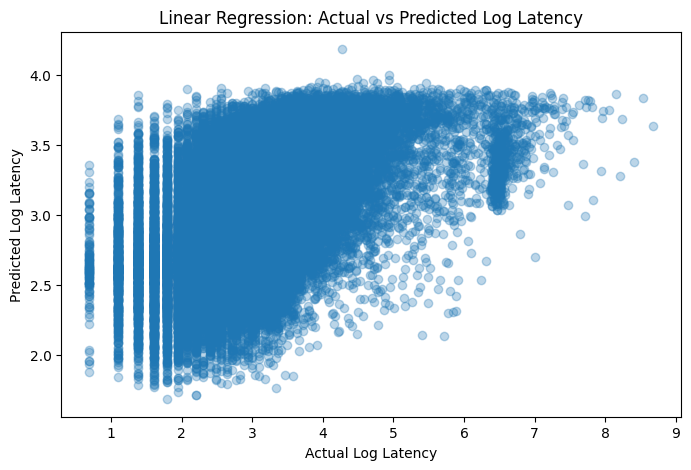

In [72]:
plt.figure(figsize=(8, 5))
plt.scatter(lr_plot_df["log_latency_ms"], lr_plot_df["prediction"], alpha=0.3)
plt.xlabel("Actual Log Latency")
plt.ylabel("Predicted Log Latency")
plt.title("Linear Regression: Actual vs Predicted Log Latency")
plt.show()

#### Interpretation:

The actual-versus-predicted plot shows that the Linear Regression model captures a general upward trend between actual and predicted log-latency values, but the predictions are compressed into a narrower range. Most predicted values fall between approximately 2.0 and 4.0, while the actual log-latency values extend much higher.

This indicates that the model performs reasonably for common or moderate latency values, but it struggles with extreme high-latency records. In particular, when actual log-latency becomes very high, the predicted values do not increase at the same rate. This suggests that the model tends to underpredict severe latency cases.

This behavior is expected from a baseline Linear Regression model because it assumes a mostly linear relationship between the predictors and the target variable. The plot supports the earlier evaluation result, where the model achieved a moderate R² score of 0.3822. Overall, Linear Regression provides a useful baseline, but the spread of points suggests that more flexible non-linear models may better capture complex latency patterns.

#### Residual Distribution

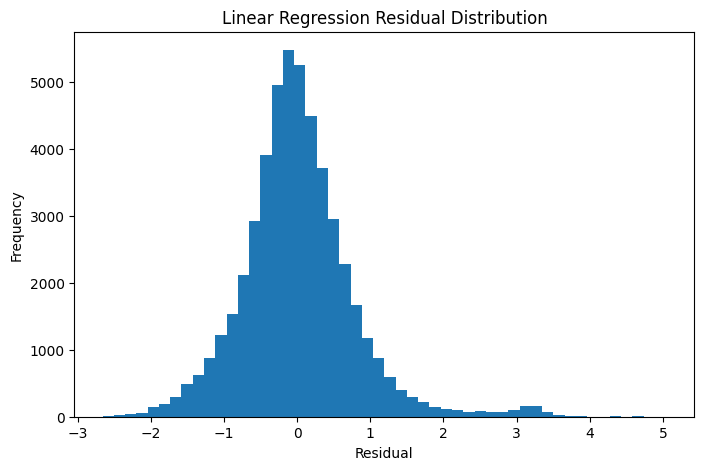

In [73]:
lr_plot_df["residual"] = lr_plot_df["log_latency_ms"] - lr_plot_df["prediction"]

plt.figure(figsize=(8, 5))
plt.hist(lr_plot_df["residual"], bins=50)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Linear Regression Residual Distribution")
plt.show()

#### Interpretation:

The residual distribution shows the difference between actual and predicted log-latency values. Most residuals are centered near zero, which means the model is able to make reasonably close predictions for many records. However, the distribution also shows a noticeable right tail, with some residuals extending above 3 and even close to 5.

Positive residuals mean that the actual log-latency was higher than the predicted value. Therefore, the right tail confirms that the Linear Regression model underpredicts some high-latency cases. This is consistent with the actual-versus-predicted plot, where extreme latency observations were not fully captured by the model.

Overall, the residual plot shows that the baseline model is useful but limited. Its errors are not evenly distributed across all latency levels, suggesting that latency may depend on non-linear relationships or additional factors not fully captured by the current linear model.

### Model 2 summary

The Linear Regression baseline provides an interpretable starting point for latency prediction. It achieved an RMSE of 0.6745, an MAE of 0.4864, and an R² score of 0.3822 on the log-transformed latency target. The visualizations show that the model captures general latency behavior but compresses predictions into a narrower range and underpredicts extreme high-latency records. These findings justify comparing the baseline model with a stronger non-linear model in the next stage.

# 9. Scalable ML Model 3: Random Forest Regression

This section trains a Random Forest Regression model to predict log-transformed latency. Unlike Linear Regression, Random Forest can capture non-linear relationships between the predictors and latency. This is useful because the Linear Regression baseline showed moderate performance and tended to underpredict extreme high-latency records.

To make the comparison fair, this model reuses the same training and testing dataframes from the Linear Regression baseline.

In [ ]:
# Step 9.1: Train Random Forest Regression model

from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="scaled_features",
    labelCol="log_latency_ms",
    predictionCol="prediction",
    numTrees=20,
    maxDepth=6,
    maxBins=32,
    seed=42,
    subsamplingRate=0.7
)

rf_model = rf.fit(train_df)

rf_predictions = rf_model.transform(test_df)

print("Random Forest Regression model trained successfully.")
print("Predictions created.")

Random Forest Regression model trained successfully.
Predictions created.


In [ ]:
# Step 9.2: Evaluate Random Forest Regression model

rf_rmse = rmse_evaluator.evaluate(rf_predictions)
rf_mae = mae_evaluator.evaluate(rf_predictions)
rf_r2 = r2_evaluator.evaluate(rf_predictions)

print("Random Forest Regression Evaluation Metrics")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE: {rf_mae:.4f}")
print(f"R²: {rf_r2:.4f}")

Random Forest Regression Evaluation Metrics
RMSE: 0.6550
MAE: 0.4696
R²: 0.4174


The Random Forest Regression model achieved an RMSE of 0.6550, an MAE of 0.4696, and an R² score of 0.4174. Compared with the Linear Regression baseline, Random Forest produced lower prediction errors and a higher R² score. This suggests that non-linear relationships exist in the dataset and that Random Forest is better able to capture some of these patterns.

However, the improvement is moderate rather than dramatic. This indicates that while non-linear modeling improves latency prediction, latency is still influenced by additional factors that may not be fully represented in the current dataset, such as routing conditions, server distance, congestion, geography, or infrastructure quality.

In [ ]:
# Step 9.3: Store Random Forest metrics

rf_metrics = {
    "model": "Random Forest Regression",
    "rmse": rf_rmse,
    "mae": rf_mae,
    "r2": rf_r2
}

rf_metrics

{'model': 'Random Forest Regression',
 'rmse': 0.6550317335752764,
 'mae': 0.4695641953846963,
 'r2': 0.41735748205474965}

In [ ]:
# Step 9.4: Create small Random Forest prediction sample for visualization

rf_plot_df = (
    rf_predictions
    .select("log_latency_ms", "prediction")
    .dropna()
    .sample(withReplacement=False, fraction=0.01, seed=42)
    .limit(50000)
    .toPandas()
)

print("Random Forest plotting sample shape:", rf_plot_df.shape)
rf_plot_df.head()

Random Forest plotting sample shape: (50000, 2)


,log_latency_ms,prediction
0,4.553877,4.213708
1,4.454347,4.154610
2,4.962845,3.978786
3,4.356709,4.223643
4,6.300786,4.132417


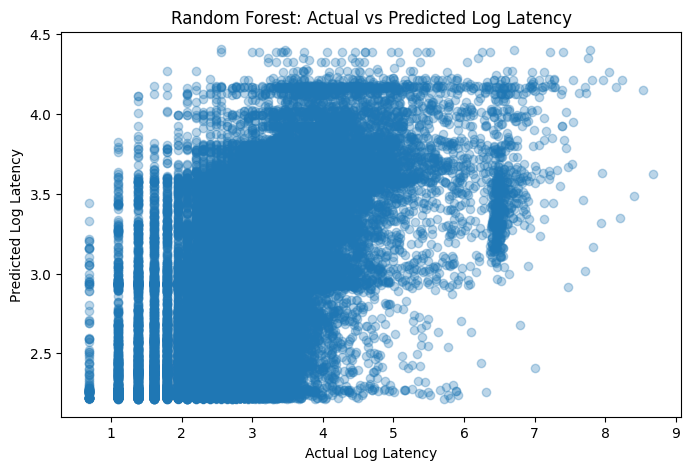

In [ ]:
# Step 9.5: Random Forest actual vs predicted log latency

plt.figure(figsize=(8, 5))
plt.scatter(rf_plot_df["log_latency_ms"], rf_plot_df["prediction"], alpha=0.3)
plt.xlabel("Actual Log Latency")
plt.ylabel("Predicted Log Latency")
plt.title("Random Forest: Actual vs Predicted Log Latency")
plt.show()

#### Interpretation:
The Random Forest actual-versus-predicted plot shows that the model captures a broader range of predicted log-latency values compared with the Linear Regression baseline. The predictions extend up to around 4.4, while Linear Regression predictions were more compressed around a narrower range. This suggests that Random Forest is better able to adjust its predictions for different network-performance conditions.

However, the plot also shows that the model still struggles with extreme high-latency records. Actual log-latency values extend beyond 7 and 8, but the predicted values do not fully reach those extreme levels. This indicates that while Random Forest improves prediction performance, it still underpredicts some severe latency cases.

Overall, the visualization supports the evaluation metrics. Random Forest performs better than Linear Regression because it captures more non-linear variation in latency, but the spread of points also shows that latency remains difficult to predict using only the available features. Additional variables such as geographic location, network congestion, routing distance, or infrastructure type may be needed to better capture extreme latency behavior.

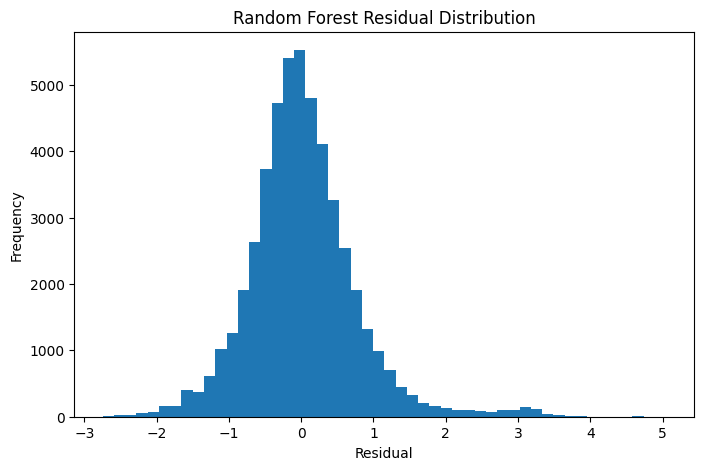

In [ ]:
# Step 9.6: Random Forest residual distribution

rf_plot_df["residual"] = rf_plot_df["log_latency_ms"] - rf_plot_df["prediction"]

plt.figure(figsize=(8, 5))
plt.hist(rf_plot_df["residual"], bins=50)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Random Forest Residual Distribution")
plt.show()

#### Interpretation:

The Random Forest residual distribution shows that most prediction errors are centered close to zero, meaning the model makes reasonably accurate predictions for many records. The distribution is slightly right-skewed, with a tail extending toward larger positive residuals. This means that, for some observations, the actual log-latency was higher than the predicted value.

This pattern indicates that Random Forest still underpredicts some high-latency cases, but the residuals are generally concentrated around zero. Compared with the Linear Regression residual plot, the Random Forest model shows slightly improved predictive behavior, which is consistent with its lower RMSE and MAE values.

Overall, the residual distribution supports the conclusion that Random Forest performs better than the linear baseline, but extreme latency remains difficult to predict. This suggests that latency may depend on additional factors not included in the current feature set, such as geographic routing, congestion, server distance, or local infrastructure conditions.


In [ ]:
# Step 9.7: Random Forest feature importance

rf_feature_cols = numeric_feature_cols + ["connection_type_index"]

feature_importance_pd = pd.DataFrame({
    "feature": rf_feature_cols,
    "importance": rf_model.featureImportances.toArray()
}).sort_values("importance", ascending=False)

feature_importance_pd

,feature,importance
1,log_upload_mbps,0.451628
8,connection_type_index,0.298803
0,log_download_mbps,0.175229
4,download_upload_ratio,0.047805
3,log_devices,0.009359
2,log_tests,0.007924
6,year,0.005556
5,tests_per_device,0.003564
7,quarter,0.000131


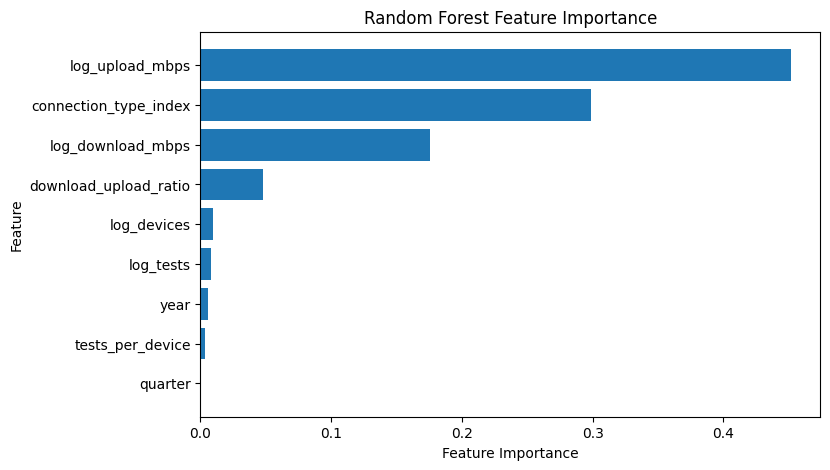

In [ ]:
# Step 9.8: Plot Random Forest feature importance

plt.figure(figsize=(8, 5))
plt.barh(feature_importance_pd["feature"], feature_importance_pd["importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

#### Feature Importance Interpretation:


The Random Forest feature importance plot shows that `log_upload_mbps` is the most influential predictor of log-transformed latency, with an importance value of around 0.4516. This suggests that upload performance contains strong information about network responsiveness. In this dataset, lower or weaker upload performance may be associated with higher latency or poorer network conditions.

The second most important feature is `connection_type_index`, with an importance value of around 0.2988. This indicates that whether a record comes from a fixed or mobile connection is highly relevant for latency prediction. This is consistent with the earlier K-Means results, where fixed and mobile records showed different cluster patterns.

The third most important feature is `log_download_mbps`, with an importance value of around 0.1752. This means download speed also contributes meaningfully to latency prediction, although it is less influential than upload speed and connection type in the Random Forest model.

Other variables, such as `download_upload_ratio`, `log_devices`, `log_tests`, `year`, `tests_per_device`, and `quarter`, have much smaller importance values. This suggests that the model relies more heavily on core network-performance variables and connection type than on time period or measurement density.

Overall, the feature importance results show that latency prediction is mainly driven by upload speed, connection type, and download speed. However, these importance values should not be interpreted as direct causal effects. They only indicate which features the Random Forest model used most when making predictions.

# 10. Model Comparison

This section compares the Linear Regression baseline and the Random Forest Regression model using RMSE, MAE, and R². The purpose is to determine whether a non-linear scalable machine learning model improves latency prediction compared with a simpler linear baseline.

In [ ]:
# Step 10.1: Compare Linear Regression and Random Forest metrics

model_comparison_pd = pd.DataFrame([
    lr_metrics,
    rf_metrics
])

model_comparison_pd

,model,rmse,mae,r2
0,Linear Regression,0.674505,0.486383,0.382200
1,Random Forest Regression,0.655032,0.469564,0.417357


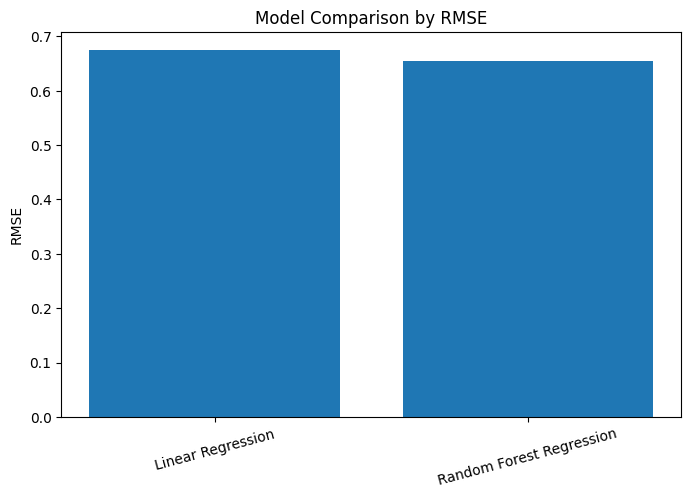

In [ ]:
# Step 10.2: Model comparison by RMSE

plt.figure(figsize=(8, 5))
plt.bar(model_comparison_pd["model"], model_comparison_pd["rmse"])
plt.ylabel("RMSE")
plt.title("Model Comparison by RMSE")
plt.xticks(rotation=15)
plt.show()

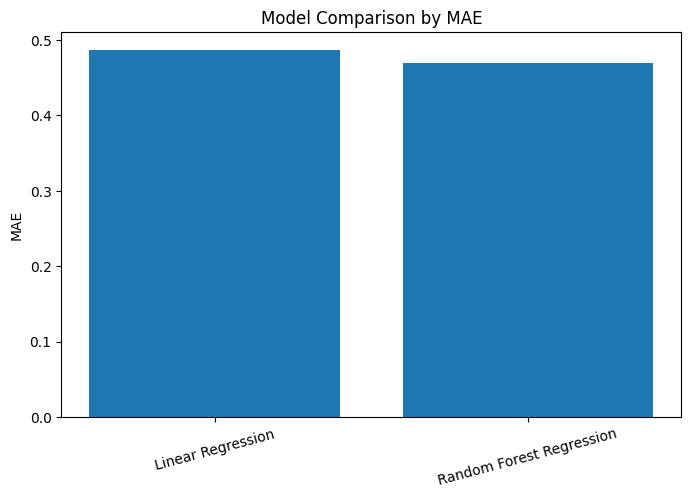

In [ ]:
# Step 10.3: Model comparison by MAE

plt.figure(figsize=(8, 5))
plt.bar(model_comparison_pd["model"], model_comparison_pd["mae"])
plt.ylabel("MAE")
plt.title("Model Comparison by MAE")
plt.xticks(rotation=15)
plt.show()

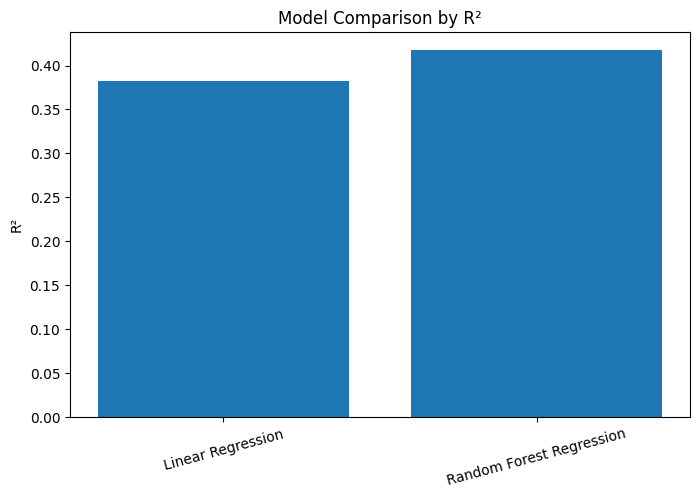

In [ ]:
# Step 10.4: Model comparison by R²

plt.figure(figsize=(8, 5))
plt.bar(model_comparison_pd["model"], model_comparison_pd["r2"])
plt.ylabel("R²")
plt.title("Model Comparison by R²")
plt.xticks(rotation=15)
plt.show()

#### Model Comparison Summary

The model comparison shows that Random Forest Regression outperformed the Linear Regression baseline across all evaluation metrics. Random Forest achieved a lower RMSE and MAE, meaning it produced smaller prediction errors on the log-transformed latency target. It also achieved a higher R² score, indicating that it explained more variance in latency than the linear baseline.

The improvement suggests that latency prediction benefits from a non-linear model. This is consistent with the earlier Linear Regression plots, where the baseline model compressed predictions into a narrower range and underpredicted extreme high-latency records. Random Forest was better able to capture some of these complex relationships, although the improvement was moderate rather than dramatic.

Overall, Linear Regression remains useful as an interpretable baseline, while Random Forest provides stronger predictive performance. However, the remaining prediction error suggests that latency is influenced by additional factors not fully captured in the dataset, such as routing distance, congestion, server placement, or local infrastructure conditions.




# Final Interpretations

In [ ]:
# Final model comparison table

model_comparison_pd

,model,rmse,mae,r2
0,Linear Regression,0.674505,0.486383,0.382200
1,Random Forest Regression,0.655032,0.469564,0.417357


The model comparison shows that Random Forest Regression performed better than the Linear Regression baseline. Random Forest achieved a lower RMSE, lower MAE, and higher R² score. This indicates that the non-linear model captured latency behavior more effectively than the linear baseline.

However, the improvement was moderate. This suggests that the available Ookla features contain useful predictive information, but latency is still influenced by factors not fully captured in the dataset, such as congestion, routing distance, server location, local infrastructure, and geographic conditions.

In [ ]:
# Display final K-Means cluster summary

cluster_summary.show(truncate=False)

+-------+--------+-----------------+---------------+--------------+---------+-----------+-------------------------+--------------------+
|cluster|records |avg_download_mbps|avg_upload_mbps|avg_latency_ms|avg_tests|avg_devices|avg_download_upload_ratio|avg_tests_per_device|
+-------+--------+-----------------+---------------+--------------+---------+-----------+-------------------------+--------------------+
|0      |24345817|78.86            |33.11          |22.75         |67.14    |17.29      |3.71                     |5.4                 |
|1      |44716375|101.74           |42.1           |21.26         |4.04     |1.92       |4.62                     |2.2                 |
|2      |54295519|14.86            |5.02           |55.69         |3.36     |1.63       |14.11                    |2.07                |
+-------+--------+-----------------+---------------+--------------+---------+-----------+-------------------------+--------------------+



The K-Means clustering model identified three interpretable internet performance tiers. Cluster 1 represents the strongest-performing tier, with the highest average download and upload speeds and the lowest average latency. Cluster 0 represents a stable or moderate-to-strong performance tier, with good speeds and relatively low latency but much higher testing activity. Cluster 2 represents the weakest-performing tier, with the lowest speeds and highest latency.

These clusters support the goal of the project by showing that scalable unsupervised learning can group large-scale internet performance records into meaningful network-performance tiers.

In [ ]:
# Save key result tables

OUTPUT_DIR = data_path / "project_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

model_comparison_pd.to_csv(OUTPUT_DIR / "model_comparison_metrics.csv", index=False)
cluster_summary.toPandas().to_csv(OUTPUT_DIR / "kmeans_cluster_summary.csv", index=False)
cluster_counts.toPandas().to_csv(OUTPUT_DIR / "kmeans_cluster_counts.csv", index=False)
cluster_connection_pivot.toPandas().to_csv(OUTPUT_DIR / "kmeans_connection_type_distribution.csv", index=False)

print("Output tables saved to:")
print(OUTPUT_DIR)

Output tables saved to:
C:\Users\ACER\Desktop\3DSA 2ND SEM\BIG DATA\GROUP SOTA\OOKLA DATASET\datasets\dhruvildave\ookla-internet-speed-dataset\versions\9\project_outputs


# 11. Limitations

This project has several limitations. First, the exploratory visualization stage used a pilot sample because full-data visualization was not practical on local hardware. However, the main feature engineering, preprocessing, clustering, and regression models were implemented using PySpark on all available Parquet files.

Second, the K-Means silhouette score was 0.2394, indicating that the clusters are only moderately separated. This is expected because real-world internet performance exists on a continuous spectrum rather than in perfectly distinct classes.

Third, the regression models predicted log-transformed latency using available network-performance variables only. Other potentially important factors, such as server distance, network congestion, routing paths, geographic infrastructure, and local service provider conditions, were not included in the dataset.

Finally, the models were implemented in a local Spark environment. Runtime and memory constraints influenced some implementation decisions, especially around visualization and avoiding full-data conversion to pandas.


# 12. Conclusion

This project implemented a scalable PySpark-based machine learning pipeline for global internet performance tiering using the Ookla network speed dataset. The pipeline processed all available Parquet performance files, engineered network-quality features, applied scalable preprocessing, performed K-Means clustering, and compared supervised regression models for latency prediction.

The K-Means model identified three interpretable performance tiers: a high-performance tier, a stable or moderate-to-strong tier, and a low-performance tier. The cluster summaries showed clear differences in download speed, upload speed, latency, connection type composition, and measurement density.

For latency prediction, Linear Regression served as the baseline model, while Random Forest Regression provided the stronger non-linear model. Random Forest outperformed Linear Regression across RMSE, MAE, and R², showing that non-linear modeling better captures latency patterns. However, the improvement was moderate, suggesting that latency is affected by additional factors beyond the available features.

Overall, the project demonstrates how scalable machine learning methods can be used to process and analyze large-scale internet performance data, producing interpretable network-performance tiers and predictive insights about latency.